# 🏨 Predicción de Cancelación de Reservas Hoteleras
##  Máster en Data Science & IA · Evolve Academy

**Dataset:** Hotel Booking Demand — Antonio, Almeida & Nunes (2019)  
**Tarea:** Clasificación binaria · `is_canceled` (37% positivos)   
**Objetivo** es Predecir aquellas reservas que tienen una alta probabilidad de ser cancaledas.  


## 0. Entorno y dependencias

In [1]:
import warnings
warnings.filterwarnings("default")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score,
    RocCurveDisplay, confusion_matrix, cohen_kappa_score,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, RandomizedSearchCV
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import LinearSVC

import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import dalex as dx
import shap

from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
RANDOM_STATE = 42

from time import perf_counter
inicio_notebook = perf_counter()


c:\Users\ALEX\Desktop\DataWorksapce\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carga y primera inspección

El dataset es público y está disponible directamente desde el repositorio de TidyTuesday (espejo del paper original).  
También puede descargarse desde Kaggle: `jessemostipak/hotel-booking-demand`.


In [2]:
import pandas as pd

df_raw = pd.read_csv("reservas_hoteleras.csv")

In [3]:
df_raw.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0000,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0000,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0000,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0000,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0000,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0000,0,0,Check-Out,2015-07-02


### Diccionario de variables
*Fuente: Antonio, Almeida & Nunes (2019). Hotel booking demand datasets. Data in Brief, 22, 41–49.*

| Variable | Tipo | Descripción |
|---|---|---|
| `hotel` | Categórica | Tipo de hotel: H1 = Resort Hotel, H2 = City Hotel |
| `is_canceled` | Binaria (target) | 1 = reserva cancelada, 0 = no cancelada |
| `lead_time` | Numérica | Días entre la fecha de reserva y la fecha de llegada |
| `arrival_date_year` | Numérica | Año de llegada |
| `arrival_date_month` | Categórica | Mes de llegada |
| `arrival_date_week_number` | Numérica | Semana del año de llegada |
| `arrival_date_day_of_month` | Numérica | Día del mes de llegada |
| `stays_in_weekend_nights` | Numérica | Noches de fin de semana (sáb/dom) reservadas o estancia real |
| `stays_in_week_nights` | Numérica | Noches entre semana (lun–vie) reservadas o estancia real |
| `adults` | Numérica | Número de adultos |
| `children` | Numérica | Número de niños |
| `babies` | Numérica | Número de bebés |
| `meal` | Categórica | Régimen alimenticio: SC/Undefined = sin paquete; BB = solo desayuno; HB = media pensión; FB = pensión completa |
| `country` | Categórica | País de origen del cliente (formato ISO 3155-3:2013) |
| `market_segment` | Categórica | Segmento de mercado. TA = Travel Agents, TO = Tour Operators |
| `distribution_channel` | Categórica | Canal de distribución de la reserva. TA = Travel Agents, TO = Tour Operators |
| `is_repeated_guest` | Binaria | 1 = cliente repetidor, 0 = primera vez |
| `previous_cancellations` | Numérica | Número de cancelaciones previas del cliente |
| `previous_bookings_not_canceled` | Numérica | Número de reservas previas no canceladas del cliente |
| `reserved_room_type` | Categórica | Código del tipo de habitación reservada (anonimizado) |
| `assigned_room_type` | Categórica | Código del tipo de habitación asignada (puede diferir de la reservada por overbooking o petición del cliente) |
| `booking_changes` | Numérica | Número de modificaciones realizadas sobre la reserva hasta check-in o cancelación |
| `deposit_type` | Categórica | Depósito realizado: No Deposit = sin depósito; Non Refund = depósito por el total de la estancia; Refundable = depósito parcial reembolsable |
| `agent` | Categórica | ID de la agencia de viajes que realizó la reserva (anonimizado) |
| `company` | Categórica | ID de la empresa responsable de la reserva o del pago (anonimizado) |
| `days_in_waiting_list` | Numérica | Días que la reserva estuvo en lista de espera antes de confirmarse |
| `customer_type` | Categórica | Tipo de reserva: Contract = con contrato; Group = grupo; Transient = individual sin contrato; Transient-party = individual asociado a otra reserva transient |
| `adr` | Numérica | Average Daily Rate: precio medio por noche (€) |
| `required_car_parking_spaces` | Numérica | Plazas de aparcamiento solicitadas por el cliente |
| `total_of_special_requests` | Numérica | Número de peticiones especiales del cliente (ej. cama doble, piso alto) |
| `reservation_status` | Categórica |  — último estado: Canceled / Check-Out / No-Show |
| `reservation_status_date` | Fecha |  — fecha en que se estableció el último estado |

In [4]:
# resumen de variables del dataframe, mostrando el tipo de dato, cantidad de nulos, porcentaje de nulos y cantidad de valores únicos. Solo se muestran las variables que tienen nulos
def resumen_variables(df):
    resumen = pd.DataFrame({
        "dtype": df.dtypes,
        "nulos": df.isnull().sum(),
        "pct_nulos": df.isnull().mean() * 100,
        "n_unique": df.nunique()
    })
    return resumen[resumen["nulos"] > 0]
resumen_variables(df_raw)


,dtype,nulos,pct_nulos,n_unique
children,float64,4,0.0034,5
country,object,488,0.4087,177
agent,float64,16340,13.6862,333
company,float64,112593,94.3069,352


In [5]:
# Distribución del target
print(df_raw["is_canceled"].value_counts())
print(f"\nTasa de cancelación: {df_raw['is_canceled'].mean():.1%}")


is_canceled
0    75166
1    44224
Name: count, dtype: int64

Tasa de cancelación: 37.0%


## 2. EDA Tecnico


### 2.1 Carga y dimensiones del dataset

Se carga el dataset original y se comprueba su número de filas y columnas.

In [6]:
df = df_raw.copy()
df.shape

(119390, 32)

### 2.2 Visualización inicial de los datos

Se muestran las primeras observaciones para obtener una primera visión de la estructura y el contenido del dataset.

In [7]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0000,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0000,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0000,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0000,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0000,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0000,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0000,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0000,NaN,0,Transient,75.0000,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0000,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0000,NaN,0,Transient,98.0000,0,1,Check-Out,2015-07-03


### 2.3 Información general del dataset

Se revisan los tipos de datos, el número de observaciones y la presencia de valores nulos en cada variable.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### 2.4 Tipos de variables

Se identifican los tipos de datos de cada variable para comprobar que son adecuados para su posterior tratamiento y análisis.

In [9]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

###  2.5 Análisis de valores nulos

Se comprueba el número de valores nulos de cada variable para identificar aquellas que requieren un tratamiento posterior.

In [10]:
df.isnull().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

| Variable | Nulos | Interpretación del nulo | Tratamiento |
|---|---|---|---|
| `company` | 112593 | No existe empresa asociada a la reserva | Eliminar |
| `agent` | 16340 | No existe agente asociado a la reserva | Imputar con `"Unknown"` |
| `country` | 488 | No se informó el país de origen | Imputar con `"Unknown"` |
| `children` | 4 | No se especificó ningún niño en la reserva | Imputar con `0` |


#### Tratamiento de `company`

La variable `company` presenta un porcentaje muy elevado de valores nulos (112.593 / 119390). En este contexto, un valor nulo indica que la reserva no está asociada a una empresa.

Dado que la variable no está informada en la gran mayoría de las reservas, imputar los valores ausentes como `"Unknown"` generaría una categoría predominante que aportaría poca información al modelo. Además, `company` actúa principalmente como un identificador de la empresa asociada y presenta una elevada cardinalidad.

Por estos motivos, se decide **eliminar la variable `company`**, ya que su elevado porcentaje de valores ausentes y su naturaleza de identificador hacen que su utilidad predictiva sea limitada.

```python
df = df.drop(columns=["company"])

In [11]:
df["children"] = df["children"].fillna(0).astype(int)
df["country"] = df["country"].fillna("Unknown")
df["agent"] = df["agent"].fillna("Unknown").astype(str)

df = df.drop(columns=["company"])

In [12]:
df.isnull().sum().sum()

np.int64(0)

### 2.6 Análisis descriptivo de las variables numéricas

El análisis descriptivo permite obtener una visión general de las variables numéricas del dataset. Se muestran medidas como la media, desviación estándar, valores mínimo y máximo, y los principales percentiles.

Esto permite detectar posibles valores atípicos, rangos inesperados y conocer la distribución general de los datos antes de continuar con el análisis.

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0000,0.3704,0.4829,0.0000,0.0000,0.0000,1.0000,1.0000
lead_time,119390.0000,104.0114,106.8631,0.0000,18.0000,69.0000,160.0000,737.0000
arrival_date_year,119390.0000,2016.1566,0.7075,2015.0000,2016.0000,2016.0000,2017.0000,2017.0000
arrival_date_week_number,119390.0000,27.1652,13.6051,1.0000,16.0000,28.0000,38.0000,53.0000
arrival_date_day_of_month,119390.0000,15.7982,8.7808,1.0000,8.0000,16.0000,23.0000,31.0000
stays_in_weekend_nights,119390.0000,0.9276,0.9986,0.0000,0.0000,1.0000,2.0000,19.0000
stays_in_week_nights,119390.0000,2.5003,1.9083,0.0000,1.0000,2.0000,3.0000,50.0000
adults,119390.0000,1.8564,0.5793,0.0000,2.0000,2.0000,2.0000,55.0000
children,119390.0000,0.1039,0.3986,0.0000,0.0000,0.0000,0.0000,10.0000
babies,119390.0000,0.0079,0.0974,0.0000,0.0000,0.0000,0.0000,10.0000


### 2.7 Interpretación del análisis descriptivo

El análisis descriptivo permite identificar los rangos y la distribución de las principales variables numéricas. En general, los valores observados son coherentes con el contexto de las reservas hoteleras.

No obstante, se identifican algunos valores que requieren una revisión adicional, especialmente en las variables **`adults`** y **`adr`**. También se observan valores máximos elevados en variables como **`lead_time`** y **`stays_in_week_nights`**, que serán revisados para determinar si corresponden a situaciones reales o a posibles anomalías.

#### 2.7.1 Revisión de la variable `adults`

Se observa la existencia de reservas con `adults = 0`, lo que no resulta coherente con una reserva hotelera convencional. Por este motivo, se revisan estos registros junto con las variables `children` y `babies`.

In [14]:
df[df["adults"] == 0][
    ["adults", "children", "babies"]
].value_counts()

adults  children  babies
0       2         0         205
        0         0         180
        3         0          11
        1         0           4
        2         1           3
Name: count, dtype: int64

In [15]:
df[df["adults"] == 0].shape[0]

403

Se identificaron **403 reservas con `adults = 0`**. Al no existir ningún adulto en estas reservas, se consideran registros anómalos y se decide excluirlos del análisis.

##### Revisión de valores elevados

Se identificaron 12 reservas con más de 10 adultos. Aunque estos valores son poco frecuentes y extremos respecto a la distribución habitual, no se consideran automáticamente errores, ya que una reserva de grupo puede incluir un número elevado de adultos.

Por este motivo, no se establece un límite arbitrario para eliminar reservas en función del número de adultos. Estos registros se mantienen para que el modelo pueda aprender si un tamaño de reserva elevado está relacionado con una mayor probabilidad de cancelación.

No obstante, durante la revisión se observa que estos 12 registros presentan además un `adr = 0` y que todos fueron cancelados. Este patrón se tendrá en cuenta posteriormente durante el análisis exploratorio y la interpretación de los resultados.

In [16]:
df[df["adults"] > 10][["adults", "children", "babies", "adr", "is_canceled"]]

,adults,children,babies,adr,is_canceled
1539,40,0,0,0.0000,1
1587,26,0,0,0.0000,1
1643,50,0,0,0.0000,1
1752,26,0,0,0.0000,1
1884,26,0,0,0.0000,1
1917,27,0,0,0.0000,1
1962,27,0,0,0.0000,1
2003,26,0,0,0.0000,1
2164,26,0,0,0.0000,1
2173,55,0,0,0.0000,1


Dado que puee deberse a un grupo de personas no decidiré sacar valores altos en `adults` solo los que son = 0 por que es imposible que en las reservas no hayan adultos

In [17]:
df = df[(df["adults"] > 0)].copy()

#### 2.7.2 Revisión de la variable `adr`

La variable `adr` representa el precio medio diario de la reserva. Por su naturaleza, un valor negativo no es económicamente coherente, por lo que se considera anómalo.

En cambio, un `adr = 0` puede representar situaciones reales, como reservas gratuitas, cortesías o casos especiales, por lo que estos registros se mantienen.

También se revisan los valores elevados de `adr`. Aunque existen reservas con valores superiores a 500, estos se consideran posibles y se mantienen. Sin embargo, se identifica un único registro con un `adr` cercano a 5.400, claramente aislado respecto al resto de observaciones, por lo que se considera un valor extremo anómalo y se elimina.

In [18]:
df[(df["adr"] < 0) | (df["adr"] > 500)]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,0,0,BB,GBR,Groups,Direct,1,0,2,A,H,2,No Deposit,273.0,0,Transient-Party,-6.3800,0,0,Check-Out,2017-03-15
15083,Resort Hotel,0,1,2015,July,29,15,0,1,2,0,0,BB,PRT,Corporate,Corporate,1,0,1,A,C,0,No Deposit,Unknown,0,Transient,508.0000,1,0,Check-Out,2015-07-16
48515,City Hotel,1,35,2016,March,13,25,0,1,2,0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,1,Non Refund,12.0,0,Transient,5400.0000,0,0,Canceled,2016-02-19
111403,City Hotel,0,0,2017,May,19,9,0,1,1,0,0,BB,ITA,Offline TA/TO,TA/TO,0,0,0,A,G,0,No Deposit,159.0,0,Transient,510.0000,0,0,Check-Out,2017-05-10


In [19]:
df = df[(df["adr"] >= 0) & (df["adr"] != 5400)].copy()

### 2.8 Identificación y eliminación de variables con data leakage

Antes de construir el modelo, es necesario identificar aquellas variables que contienen información que **no estaría disponible en el momento de realizar la reserva**.

Las variables `reservation_status` y `reservation_status_date` reflejan el estado final de la reserva y la fecha en la que se produjo dicho estado. Utilizarlas como variables predictoras permitiría al modelo conocer información posterior a la reserva, provocando **data leakage** y dando lugar a resultados artificialmente elevados.

Por este motivo, estas variables se eliminan del conjunto de datos. La variable `is_canceled` también se separa del conjunto de predictores, ya que constituye la **variable objetivo** que el modelo deberá predecir.Ahora veamos que columnas eliminar que nos dan información del futuro como is_canceled y así las quitamos

In [20]:
y = df["is_canceled"]

leakage_cols = [
    "reservation_status",
    "reservation_status_date",
    "booking_changes",
    "assigned_room_type"
]

df = df.drop(columns=leakage_cols)

### 2.9 Detección de duplicados

Se comprueba la existencia de registros completamente duplicados en el dataset.

In [21]:
df.duplicated().sum()

np.int64(34037)

Se revisan los registros duplicados para confirmar que se trata de observaciones idénticas en todas sus variables.

In [22]:
duplicados = df[df.duplicated(keep=False)]

duplicados.head(20)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,No Deposit,240.0,0,Transient,98.0000,0,1
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,No Deposit,240.0,0,Transient,98.0000,0,1
21,Resort Hotel,0,72,2015,July,27,1,2,4,2,0,0,BB,PRT,Direct,Direct,0,0,0,A,No Deposit,250.0,0,Transient,84.6700,0,1
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,0,0,BB,PRT,Direct,Direct,0,0,0,A,No Deposit,250.0,0,Transient,84.6700,0,1
39,Resort Hotel,0,70,2015,July,27,2,2,3,2,0,0,HB,ROU,Direct,Direct,0,0,0,E,No Deposit,250.0,0,Transient,137.0000,0,1
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,0,0,HB,ROU,Direct,Direct,0,0,0,E,No Deposit,250.0,0,Transient,137.0000,0,1
132,Resort Hotel,1,5,2015,July,28,5,1,0,2,0,0,BB,PRT,Online TA,TA/TO,0,0,0,D,No Deposit,240.0,0,Transient,97.0000,0,0
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,0,0,BB,PRT,Online TA,TA/TO,0,0,0,D,No Deposit,240.0,0,Transient,97.0000,0,0
198,Resort Hotel,0,0,2015,July,28,7,0,1,1,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,No Deposit,240.0,0,Transient,109.8000,0,3
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,No Deposit,240.0,0,Transient,109.8000,0,3


Se agrupan los registros por todas las variables para comprobar la frecuencia de las observaciones duplicadas.

In [23]:
duplicados.groupby(
    list(df.columns)
).size().sort_values(ascending=False).head(10)

hotel       is_canceled  lead_time  arrival_date_year  arrival_date_month  arrival_date_week_number  arrival_date_day_of_month  stays_in_weekend_nights  stays_in_week_nights  adults  children  babies  meal  country  market_segment  distribution_channel  is_repeated_guest  previous_cancellations  previous_bookings_not_canceled  reserved_room_type  deposit_type  agent    days_in_waiting_list  customer_type    adr       required_car_parking_spaces  total_of_special_requests
City Hotel  1            277        2016               November            46                        7                          1                        2                     2       0         0       BB    PRT      Groups          TA/TO                 0                  0                       0                               A                   Non Refund    Unknown  0                     Transient        100.0000  0                            0                            180
                         68         2016 

Se detectan filas con valores idénticos en las variables disponibles.
Sin embargo, no existe un identificador de reserva que permita
confirmar que corresponden a registros duplicados por error.

Se conservan estas observaciones, ya que eliminarlas podría
alterar el volumen de reservas y la distribución de cancelaciones.Los registros completamente duplicados no aportan información adicional y podrían dar un peso excesivo a determinadas observaciones. Por ello, se conserva una única copia de cada registro.

### 2.10 Comprobación final de calidad del dataset

In [24]:
def resumen_calidad(df):
    print("===== RESUMEN DE CALIDAD DEL DATASET =====\n")
    
    # Dimensiones
    filas, columnas = df.shape
    print(f"Filas: {filas:,}")
    print(f"Columnas: {columnas:,}")
    
    # Nulos
    nulos = df.isnull().sum().sum()
    print(f"\nNulos totales: {nulos:,}")
    
    # Anomalías
    adr_negativo = (df["adr"] < 0).sum()
    adultos_cero = (df["adults"] == 0).sum()
    
    print(f"\nADR negativo: {adr_negativo:,}")
    print(f"Reservas con adults = 0: {adultos_cero:,}")
    
    # Estado final
    if nulos == 0 and adr_negativo == 0 and adultos_cero == 0:
        print("\nNo se detectan incidencias en las comprobaciones aplicadas.")
    else:
        print("\nHay incidencias en las comprobaciones aplicadas.")


resumen_calidad(df)

===== RESUMEN DE CALIDAD DEL DATASET =====

Filas: 118,985
Columnas: 27

Nulos totales: 0

ADR negativo: 0
Reservas con adults = 0: 0

No se detectan incidencias en las comprobaciones aplicadas.


---
## 3. EDA Negocio

El objetivo de este análisis es identificar dónde se concentran las
cancelaciones y qué características de las reservas están asociadas
con una mayor tasa de cancelación.

Se estudian cinco dimensiones: hotel, mes de llegada, canal de
distribución, antelación de la reserva y precio medio diario (ADR).

En cada análisis se diferencia entre:

- **Volumen de reservas:** tamaño del grupo analizado.
- **Número de cancelaciones:** contribución del grupo al problema.
- **Tasa de cancelación:** porcentaje de reservas canceladas dentro
  del grupo.

Esta distinción permite identificar tanto los grupos con mayor
frecuencia de cancelación como aquellos donde una intervención
podría alcanzar un mayor número de reservas.

Se mantienen los filtros de adultos y ADR definidos en la revisión
técnica. No se eliminan filas repetidas, ya que no se dispone de un
identificador que permita confirmar que corresponden a la misma reserva.

Las relaciones observadas son descriptivas y no demuestran causalidad.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

# Copia independiente para el análisis de negocio.
df_eda = df_raw.loc[
    (df_raw["adults"] > 0)
    & (df_raw["adults"] <= 10)
    & (df_raw["adr"] >= 0)
    & (df_raw["adr"] != 5400)
].copy()

tasa_global = df_eda["is_canceled"].mean()

print(f"Reservas analizadas: {len(df_eda):,}")
print(f"Reservas canceladas: {df_eda['is_canceled'].sum():,}")
print(f"Tasa de cancelación: {tasa_global:.2%}")


def resumir_cancelaciones(variable):
    tabla = (
        df_eda.groupby(variable, observed=True, dropna=False)
        .agg(
            reservas=("is_canceled", "size"),
            cancelaciones=("is_canceled", "sum"),
            tasa_cancelacion=("is_canceled", "mean")
        )
    )

    tabla["peso_cancelaciones"] = (
        tabla["cancelaciones"] / df_eda["is_canceled"].sum()
    )
    return tabla


def mostrar_tabla(tabla):
    display(tabla.style.format({
        "reservas": "{:,.0f}",
        "cancelaciones": "{:,.0f}",
        "tasa_cancelacion": "{:.2%}",
        "peso_cancelaciones": "{:.2%}"
    }))


def graficar_cancelaciones(tabla, titulo):
    fig, axes = plt.subplots(
        1, 2, figsize=(13, max(3.5, len(tabla) * 0.55))
    )

    etiquetas = tabla.index.astype(str)
    posiciones = np.arange(len(tabla))

    axes[0].barh(
        posiciones, tabla["reservas"], color="#CBD5E1",
        label="Total de reservas"
    )
    axes[0].barh(
        posiciones, tabla["cancelaciones"], color="#D97757",
        label="Canceladas"
    )
    axes[0].set_yticks(posiciones)
    axes[0].set_yticklabels(etiquetas)
    axes[0].invert_yaxis()
    axes[0].set_title("Volumen de reservas")
    axes[0].set_xlabel("Número de reservas")
    axes[0].legend()

    barras = axes[1].barh(
        posiciones, tabla["tasa_cancelacion"], color="#347A93"
    )
    axes[1].set_yticks(posiciones)
    axes[1].set_yticklabels(etiquetas)
    axes[1].invert_yaxis()
    axes[1].set_xlim(0, 1.15)
    axes[1].set_xticks(np.linspace(0, 1, 6))
    axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1))
    axes[1].axvline(
        tasa_global, color="black", linestyle="--",
        label=f"Global: {tasa_global:.1%}"
    )
    axes[1].bar_label(
        barras,
        labels=[f"{valor:.1%}" for valor in tabla["tasa_cancelacion"]],
        padding=4
    )
    axes[1].set_title("Tasa de cancelación")
    axes[1].legend()

    fig.suptitle(titulo, fontsize=14)
    plt.tight_layout()
    plt.show()

Reservas analizadas: 118,973
Reservas canceladas: 44,102
Tasa de cancelación: 37.07%


### 3.1 Cancelaciones por hotel

Se compara el volumen de reservas y la tasa de cancelación de cada
hotel para determinar dónde conviene priorizar las actuaciones.

,reservas,cancelaciones,tasa_cancelacion,peso_cancelaciones
hotel,,,,
City Hotel,"78,939","32,994",41.80%,74.81%
Resort Hotel,"40,034","11,108",27.75%,25.19%


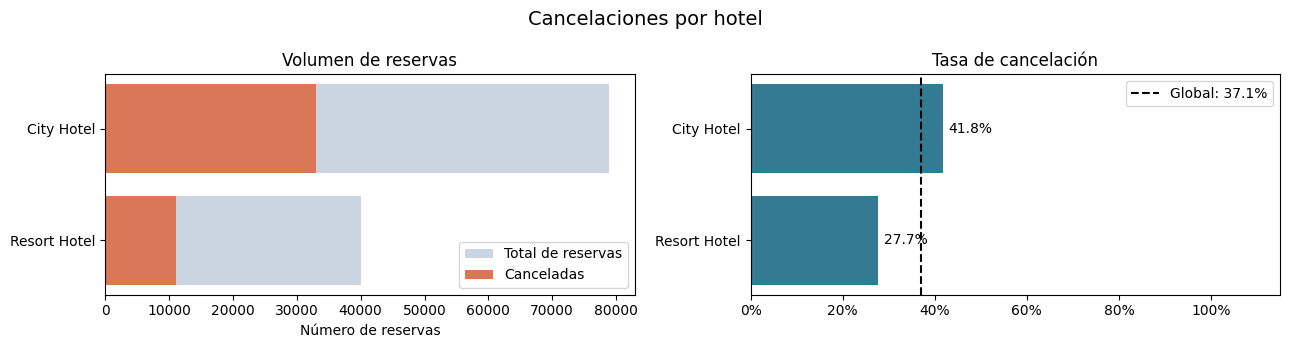

In [26]:
tabla_hotel = resumir_cancelaciones("hotel").sort_values(
    "tasa_cancelacion", ascending=False
)

mostrar_tabla(tabla_hotel) ## hacer si da errores %pip install jinja2

graficar_cancelaciones(tabla_hotel, "Cancelaciones por hotel")

**Conclusión:** City Hotel cancela el **41,80 % de sus reservas**, frente al **27,75 % de Resort Hotel**. Además, concentra el **74,81 % de todas las cancelaciones**, combinando una mayor tasa con un mayor volumen.

**Acción propuesta:** priorizar en City Hotel un piloto de seguimiento de reservas y analizar si las diferencias se explican por el canal o la antelación.

### 3.2 ¿Cómo evoluciona la cancelación por mes de llegada?

Se analiza el volumen de reservas y la tasa de cancelación por
año y mes de llegada.

El mes corresponde a la llegada prevista, no al momento en que se
produjo la cancelación. Por tanto, este análisis muestra qué cohortes
de llegada registraron más cancelaciones.

,reservas,cancelaciones,tasa_cancelacion,peso_cancelaciones
mes_llegada,,,,
2015-07,"2,774","1,259",45.39%,2.85%
2015-08,"3,879","1,598",41.20%,3.62%
2015-09,"5,101","2,085",40.87%,4.73%
2015-10,"4,945","1,727",34.92%,3.92%
2015-11,"2,337",486,20.80%,1.10%
2015-12,"2,904",969,33.37%,2.20%
2016-01,"2,238",555,24.80%,1.26%
2016-02,"3,871","1,332",34.41%,3.02%
2016-03,"4,808","1,471",30.59%,3.34%


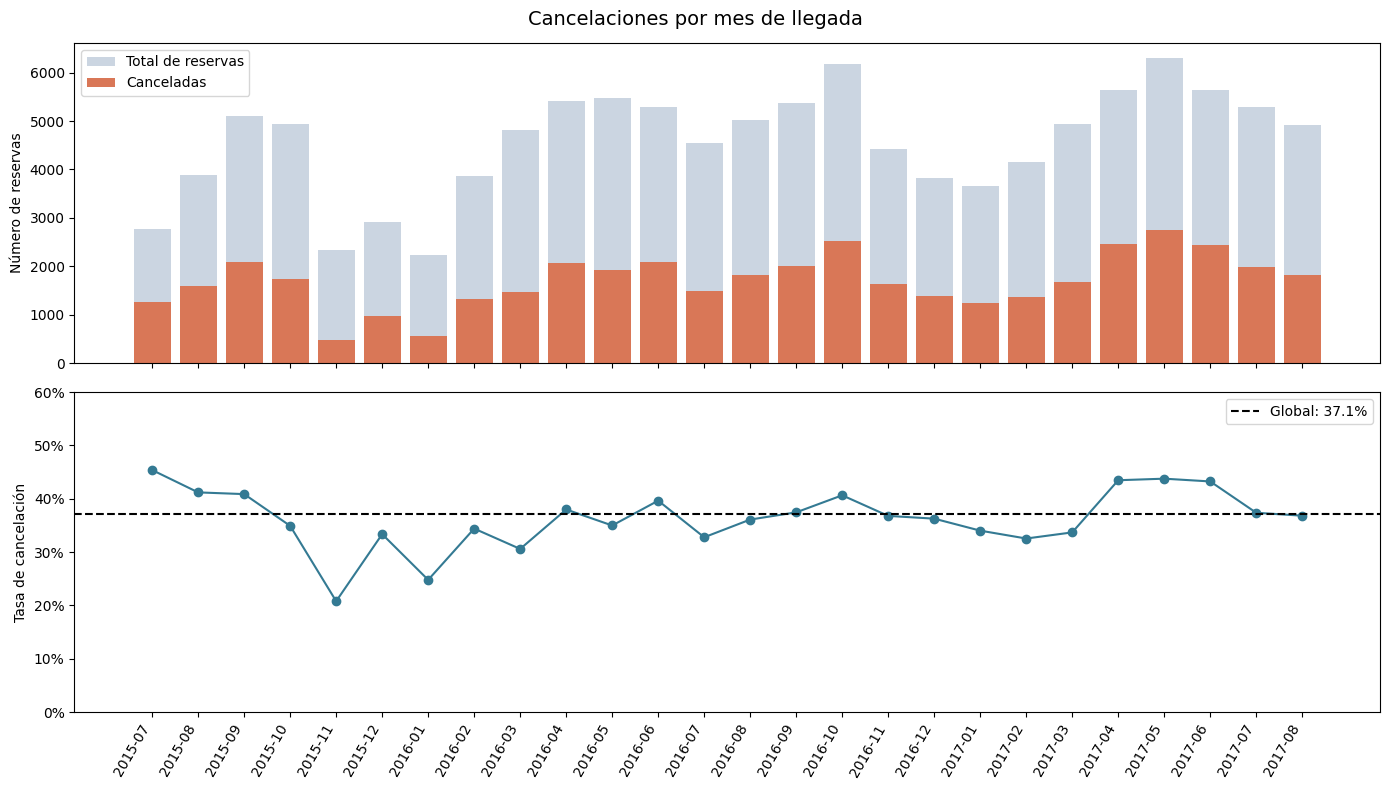

In [27]:
meses = {
    "January": 1, "February": 2, "March": 3,
    "April": 4, "May": 5, "June": 6,
    "July": 7, "August": 8, "September": 9,
    "October": 10, "November": 11, "December": 12
}

df_eda["fecha_llegada"] = pd.to_datetime({
    "year": df_eda["arrival_date_year"],
    "month": df_eda["arrival_date_month"].map(meses),
    "day": df_eda["arrival_date_day_of_month"]
})

df_eda["mes_llegada"] = (
    df_eda["fecha_llegada"].dt.to_period("M")
)

tabla_mes = resumir_cancelaciones("mes_llegada").sort_index()
mostrar_tabla(tabla_mes)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
x = np.arange(len(tabla_mes))

axes[0].bar(
    x, tabla_mes["reservas"], color="#CBD5E1", label="Total de reservas"
)
axes[0].bar(
    x, tabla_mes["cancelaciones"], color="#D97757", label="Canceladas"
)
axes[0].set_ylabel("Número de reservas")
axes[0].legend()

axes[1].plot(
    x, tabla_mes["tasa_cancelacion"],
    marker="o", color="#347A93"
)
axes[1].axhline(
    tasa_global, color="black", linestyle="--",
    label=f"Global: {tasa_global:.1%}"
)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[1].set_ylim(0, 0.60)
axes[1].set_ylabel("Tasa de cancelación")
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    tabla_mes.index.astype(str), rotation=60, ha="right"
)
axes[1].legend()

fig.suptitle("Cancelaciones por mes de llegada", fontsize=14)
plt.tight_layout()
plt.show()

**Conclusión:** La tasa de cancelación varía entre el **20,80 % y el 45,39 %** según el mes de llegada. **Mayo de 2017 registra más cancelaciones, con 2.756**, aunque no presenta la mayor tasa.

**Implicación de negocio:** ajustar las previsiones de llegadas por periodo. Se observa variación temporal, pero no puede confirmarse una estacionalidad estable porque solo se dispone de un año natural completo.

### 3.3 ¿Qué canales concentran las cancelaciones?

Se compara la tasa de cancelación de los canales de distribución y
su contribución al total de cancelaciones.

Las categorías con pocas reservas se interpretan con cautela,
ya que unas pocas observaciones pueden producir tasas extremas.

,reservas,cancelaciones,tasa_cancelacion,peso_cancelaciones
distribution_channel,,,,
TA/TO,"97,554","40,054",41.06%,90.82%
Direct,"14,570","2,540",17.43%,5.76%
Corporate,"6,651","1,467",22.06%,3.33%
GDS,193,37,19.17%,0.08%
Undefined,5,4,80.00%,0.01%


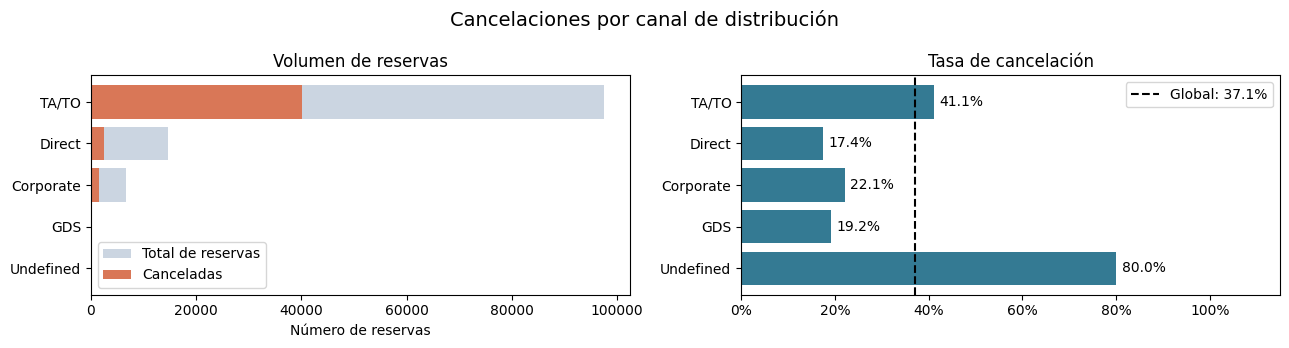

In [28]:
tabla_canal = resumir_cancelaciones(
    "distribution_channel"
).sort_values("cancelaciones", ascending=False)

mostrar_tabla(tabla_canal)
graficar_cancelaciones(
    tabla_canal, "Cancelaciones por canal de distribución"
)

**Conclusión:** El canal **TA/TO presenta una tasa de cancelación del 41,06 %**, frente al **17,43 % del canal directo**, y concentra el **90,8 % de las cancelaciones**. La categoría `Undefined` solo incluye cinco reservas, por lo que su tasa no permite extraer conclusiones fiables.

**Acción propuesta:** analizar qué agencias y condiciones de reserva concentran las cancelaciones antes de modificar las políticas comerciales.

### 3.4 ¿Se cancelan más las reservas realizadas con antelación?

Se agrupa `lead_time` en intervalos de días para analizar cómo
varía la tasa de cancelación según el tiempo transcurrido entre
la reserva y la llegada prevista.

,reservas,cancelaciones,tasa_cancelacion,peso_cancelaciones
tramo_antelacion,,,,
0–7 días,"19,617","1,883",9.60%,4.27%
8–30 días,"18,918","5,272",27.87%,11.95%
31–90 días,"29,474","11,124",37.74%,25.22%
91–180 días,"26,366","11,799",44.75%,26.75%
181–365 días,"21,452","11,896",55.45%,26.97%
Más de 365 días,"3,146","2,128",67.64%,4.83%


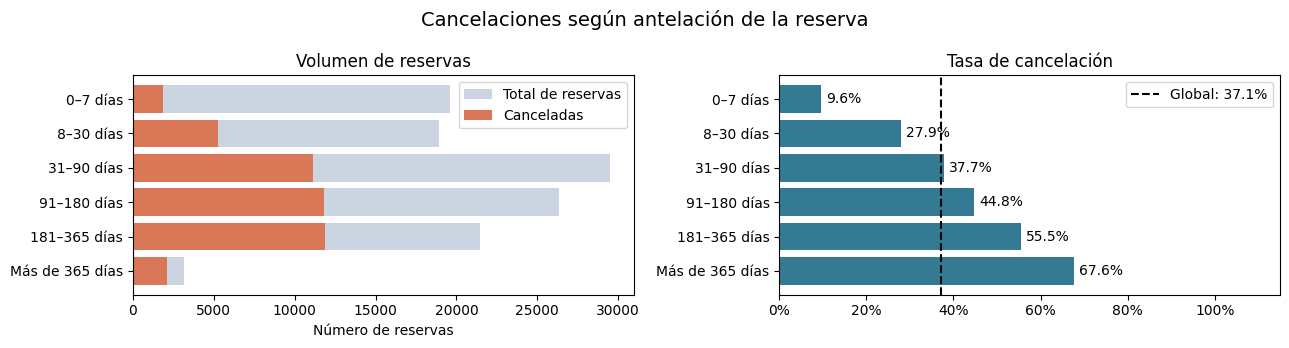

In [29]:
df_eda["tramo_antelacion"] = pd.cut(
    df_eda["lead_time"],
    bins=[-1, 7, 30, 90, 180, 365, np.inf],
    labels=[
        "0–7 días",
        "8–30 días",
        "31–90 días",
        "91–180 días",
        "181–365 días",
        "Más de 365 días"
    ]
)

tabla_antelacion = resumir_cancelaciones("tramo_antelacion")

mostrar_tabla(tabla_antelacion)
graficar_cancelaciones(
    tabla_antelacion, "Cancelaciones según antelación de la reserva"
)

**Conclusión:** La tasa de cancelación aumenta con la antelación: pasa del **9,6 % en reservas realizadas con hasta siete días** al **67,6 % en las realizadas con más de un año**. El tramo de **181 a 365 días concentra el mayor número de cancelaciones: 11.896**.

**Acción propuesta:** probar recordatorios y reconfirmaciones en reservas con más de seis meses de antelación y evaluar si reducen las cancelaciones.

### 3.5 ¿Qué relación existe entre el ADR y las cancelaciones?

Se compara el ADR de las reservas canceladas y no canceladas
mediante la media y la mediana.

También se realiza la comparación dentro de cada hotel para
comprobar si el patrón global se mantiene en ambos establecimientos.

El ADR representa una tarifa media diaria. No equivale al ingreso
neto perdido por una cancelación.

,reservas,adr_medio,adr_mediano
estado,,,
No cancelada,"74,871",100.21,92.83
Cancelada,"44,102",104.97,96.30


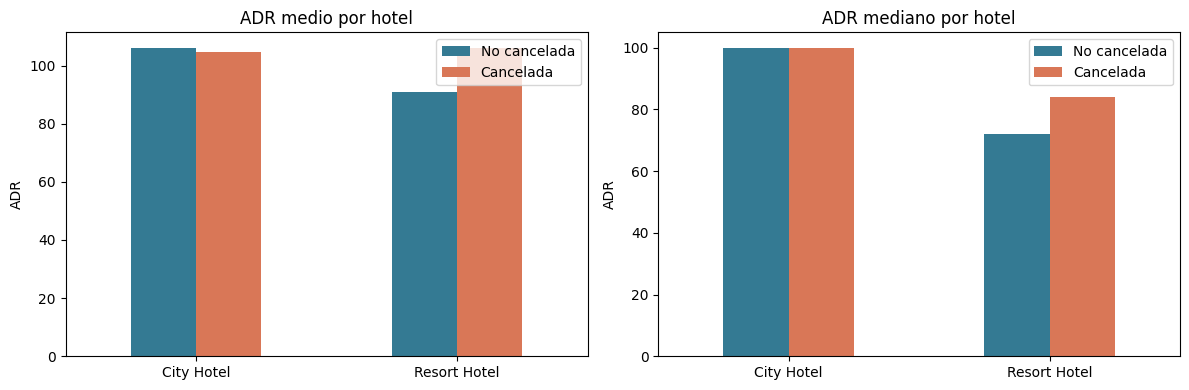

In [30]:
df_eda["estado"] = df_eda["is_canceled"].map({
    0: "No cancelada",
    1: "Cancelada"
})

resumen_adr = (
    df_eda.groupby("estado")
    .agg(
        reservas=("adr", "size"),
        adr_medio=("adr", "mean"),
        adr_mediano=("adr", "median")
    )
    .reindex(["No cancelada", "Cancelada"])
)

resumen_adr_hotel = (
    df_eda.groupby(["hotel", "estado"])
    .agg(
        reservas=("adr", "size"),
        adr_medio=("adr", "mean"),
        adr_mediano=("adr", "median")
    )
)

formato_adr = {
    "reservas": "{:,.0f}",
    "adr_medio": "{:.2f}",
    "adr_mediano": "{:.2f}"
}

display(resumen_adr.style.format(formato_adr))
display(resumen_adr_hotel.style.format(formato_adr))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metrica, titulo in zip(
    axes,
    ["adr_medio", "adr_mediano"],
    ["ADR medio por hotel", "ADR mediano por hotel"]
):
    (
        resumen_adr_hotel[metrica]
        .unstack("estado")
        .reindex(columns=["No cancelada", "Cancelada"])
        .plot.bar(
            ax=ax, color=["#347A93", "#D97757"], rot=0
        )
    )
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.set_ylabel("ADR")
    ax.legend(title="")

plt.tight_layout()
plt.show()

**Conclusión:** Las reservas canceladas presentan un ADR medio mayor: **104,97 frente a 100,21**. Sin embargo, el patrón cambia por hotel: en **Resort Hotel** las canceladas tienen un ADR mayor y en **City Hotel**, ligeramente menor.

**Implicación de negocio:** no se justifica una bajada general de precios. Conviene analizar la tarifa junto con el hotel, la temporada y el canal. El valor de una reserva cancelada tampoco equivale necesariamente a una pérdida neta de ingresos.

### 3.6 Conclusiones de negocio

La tasa de cancelación de la base analizada es del **37,07 %**.
Los resultados sugieren tres prioridades de investigación y actuación:

1. **Priorizar City Hotel.** Presenta una mayor tasa de cancelación
   y concentra el mayor número de reservas canceladas.

2. **Profundizar en TA/TO.** Este canal concentra aproximadamente
   el 90,8 % de las cancelaciones. Es necesario identificar qué
   agencias, condiciones o perfiles explican esa concentración.

3. **Probar seguimiento de reservas con mucha antelación.**
   La tasa supera el 55 % en reservas realizadas entre seis meses
   y un año antes de la llegada.

Estas prioridades se solapan: una misma reserva puede pertenecer
a City Hotel, proceder de TA/TO y haberse realizado con mucha
antelación. Sus volúmenes no deben sumarse como oportunidades
independientes.

La evolución mensual aconseja incorporar el tiempo al análisis.
Por su parte, el ADR muestra patrones distintos según el hotel
y no respalda una política general de reducción de precios.

Como siguiente paso, se propone evaluar un piloto de seguimiento
sobre un grupo de reservas y compararlo con un grupo de control.
El resultado debe medirse mediante la reducción de cancelaciones,
el margen adicional y el coste de la intervención.

---
## 4. Feature Engineering


El feature engineering consiste en crear nuevas variables a partir de las variables disponibles, con el objetivo de representar de forma más útil las características de cada reserva para el modelo predictivo.

Las nuevas variables se seleccionan teniendo en cuenta su posible utilidad desde el punto de vista del negocio y su disponibilidad en el momento de realizar la reserva.

**Regla:** si no se puede justificar por qué una variable podría aportar información para predecir una cancelación, no se incluye.

### 4.1 Tamaño total del grupo

Se crea `total_guests` para representar el número total de personas incluidas en la reserva.

Esta variable permite al modelo captar de forma directa el tamaño del grupo, que puede estar relacionado con el comportamiento de cancelación.

In [31]:
df["total_guests"] = (
    df["adults"] +
    df["children"] +
    df["babies"]
)

### 4.2 Duración total de la estancia

Se crea `total_nights` como la suma de las noches entre semana y durante el fin de semana.

Esta variable resume la duración total de la estancia y permite al modelo utilizar directamente una medida del tamaño temporal de la reserva.

In [32]:
df["total_nights"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

### 4.3 Valor total de la reserva

Se crea `total_stay_value` multiplicando el ADR por el número total de noches.

Esta variable aproxima el valor económico de la estancia y puede ayudar a identificar diferencias en el comportamiento de cancelación según el importe de la reserva.

In [33]:
df["total_stay_value"] = (
    df["adr"] *
    df["total_nights"]
)

In [34]:
meses = {
    "January": 1, "February": 2, "March": 3,
    "April": 4, "May": 5, "June": 6,
    "July": 7, "August": 8, "September": 9,
    "October": 10, "November": 11, "December": 12
}

df["arrival_date"] = pd.to_datetime(
    dict(
        year=df["arrival_date_year"],
        month=df["arrival_date_month"].map(meses),
        day=df["arrival_date_day_of_month"]
    )
)

---
## 5. Train y Test

Se realiza una partición temporal de los datos, utilizando el **80 % de las reservas más antiguas para Train** y el **20 % más reciente para Test**.

De esta forma, el modelo se entrena con información pasada y se evalúa sobre reservas posteriores, simulando un escenario real de predicción.

Finalmente, se separan las variables predictoras (`X`) de la variable objetivo (`y = is_canceled`).

In [35]:
df = df.sort_values("arrival_date").reset_index(drop=True)

posicion_corte = int(len(df) * 0.80)
fecha_corte = df.iloc[posicion_corte]["arrival_date"]

train = df.loc[df["arrival_date"] < fecha_corte].copy()
test = df.loc[df["arrival_date"] >= fecha_corte].copy()

assert train["arrival_date"].max() < test["arrival_date"].min()

In [36]:
X_train = train.drop(columns=["is_canceled", "arrival_date"])
y_train = train["is_canceled"]

X_test = test.drop(columns=["is_canceled", "arrival_date"])
y_test = test["is_canceled"]

### Resumen de la partición

Se comprueba que Train contiene las reservas más antiguas y Test las reservas más recientes, manteniendo la estructura temporal del dataset.

Además, se verifica que la variable objetivo `is_canceled` se ha separado correctamente de las variables predictoras.

In [37]:
print("===== TRAIN =====")
print(f"Filas: {len(train):,}")
print(f"Periodo: {train['arrival_date'].min().date()} → {train['arrival_date'].max().date()}")

print("\n===== TEST =====")
print(f"Filas: {len(test):,}")
print(f"Periodo: {test['arrival_date'].min().date()} → {test['arrival_date'].max().date()}")

print("\n===== PROPORCIÓN =====")
print(f"Train: {len(train) / len(df):.1%}")
print(f"Test: {len(test) / len(df):.1%}")

===== TRAIN =====
Filas: 94,999
Periodo: 2015-07-01 → 2017-04-21

===== TEST =====
Filas: 23,986
Periodo: 2017-04-22 → 2017-08-31

===== PROPORCIÓN =====
Train: 79.8%
Test: 20.2%


---
## 6. Preprocesado

Antes de entrenar los modelos es necesario transformar las variables para que puedan ser utilizadas correctamente por los algoritmos de Machine Learning.

Aplicaremos transformaciones a las variables como **One-Hot Encoding**, **StandardScaler** o **Outliers**.

El preprocesado se ajustará únicamente con los datos de **Train** y posteriormente se aplicará a **Test**, evitando así posibles problemas de Data Leakage.

La variable `arrival_date` no se utilizará como predictor, ya que se ha creado únicamente para realizar la partición temporal.

### 6.1 Escalado de variables numéricas

Las variables numéricas se escalan mediante **StandardScaler** para que tengan una escala comparable.

In [38]:
numeric_features = [
    "lead_time",
    "arrival_date_year",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "total_guests",
    "total_nights",
    "total_stay_value"
]

scaler = StandardScaler()

### 6.2 Codificación de variables categóricas

Las variables categóricas se transforman mediante **One-Hot Encoding**, creando una variable binaria para cada categoría.

De esta forma, el modelo puede utilizar variables categóricas sin introducir un orden artificial entre sus categorías.

In [39]:
categorical_features = [
    "hotel",
    "arrival_date_month",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "deposit_type",
    "agent",
    "customer_type"
]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

### 6.3 Variables binarias y variables excluidas

Las variables binarias, como `is_repeated_guest`, ya están representadas mediante 0 y 1, por lo que no necesitan One-Hot Encoding.

La variable `arrival_date` tampoco se utilizará como predictor, ya que se creó únicamente para realizar la partición temporal de los datos.

La variable `is_canceled` es la variable objetivo y no forma parte de las variables predictoras.

In [40]:
binary_features = [
    "is_repeated_guest"
]

# arrival_date → solo utilizada para la partición temporal
# is_canceled → variable objetivo

### 6.4 Preprocesador completo

Se combinan el escalado de las variables numéricas y la codificación de las variables categóricas mediante un `ColumnTransformer`.

El preprocesador se ajustará posteriormente únicamente con los datos de Train y se aplicará después a Test, evitando así Data Leakage.

In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ), categorical_features)
    ],
    remainder="passthrough"
)

---
## 7. Modelado

### 7.1 Modelo Baseline — Regresión Logística

El baseline sirve como modelo de referencia. A partir de sus resultados podremos comprobar si modelos más complejos consiguen mejorar el rendimiento de forma justificada.


In [42]:
# Para visalizar resultados más adelante tenemos que crear un contenedor para ir metiendo los modelos
resultados_modelos = []

In [43]:
logistic_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](29,)","['hotel','lead_time','arrival_date_year',...,'total_guests','total_nights', 'total_stay_value']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remaind

Se obtienen las clases predichas y las probabilidades de cancelación
en Test. También se calcula el AUC en Train para comparar el
rendimiento entre entrenamiento y evaluación e identificar posibles
señales de sobreajuste.

In [44]:
# Predicciones en test
y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

# Probabilidades en entrenamiento
prob_train_logistic = logistic_model.predict_proba(X_train)[:, 1]

# AUC de entrenamiento y test
auc_train_logistic = roc_auc_score(y_train, prob_train_logistic)
auc_test_logistic = roc_auc_score(y_test, y_prob_logistic)

Se registran el AUC de Train y Test, su diferencia, F1, precision
y recall, utilizando las mismas métricas que en los modelos
anteriores para facilitar la comparación.

In [45]:
resultado_logistic = {
    "Name": "Regresión Logística",
    "AUC Train": auc_train_logistic,
    "AUC Test": auc_test_logistic,
    "Diferencia AUC": auc_train_logistic - auc_test_logistic,
    "F1 Test": f1_score(y_test, y_pred_logistic, zero_division=0),
    "Precision Test": precision_score(
        y_test, y_pred_logistic, zero_division=0
    ),
    "Recall Test": recall_score(
        y_test, y_pred_logistic, zero_division=0
    ),
    "Kappa Test": cohen_kappa_score(y_test, y_pred_logistic)
}

La matriz permite distinguir las cancelaciones detectadas, las
cancelaciones que pasan inadvertidas y las falsas alarmas.

Estos errores tienen implicaciones distintas: una cancelación no
detectada reduce la capacidad de anticipación, mientras que una
falsa alarma puede generar una intervención innecesaria.

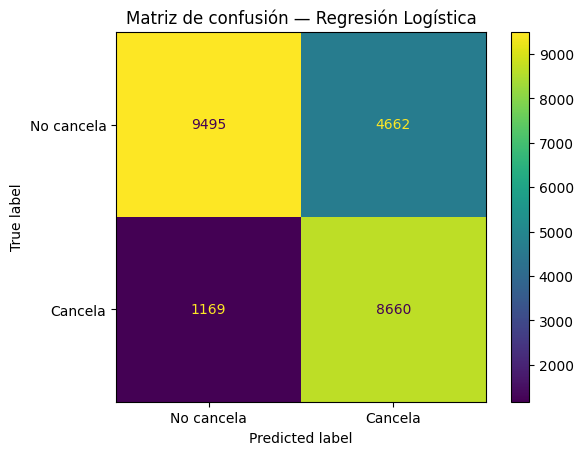

In [46]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    display_labels=["No cancela", "Cancela"]
)

plt.title("Matriz de confusión — Regresión Logística")
plt.show()

### 7.2 Comparación de modelos

Se entrenan diferentes algoritmos de clasificación y se comparan sus resultados utilizando las mismas métricas y el mismo procedimiento de validación.

#### 7.2.1 Árbol de Decisión

Se utiliza un Árbol de Decisión como segundo modelo para comprobar si una estructura no lineal permite mejorar los resultados obtenidos con la Regresión Logística.

A diferencia de la Regresión Logística, el árbol puede capturar relaciones no lineales e interacciones entre las variables de la reserva.

Se mantiene el mismo preprocesamiento y la misma partición Train/Test para que la comparación con el baseline sea consistente.

In [47]:
decision_tree_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", DecisionTreeClassifier(
        criterion="gini",
        max_depth=4,
        class_weight="balanced",
        random_state=42
    ))
])

decision_tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](29,)","['hotel','lead_time','arrival_date_year',...,'total_guests','total_nights', 'total_stay_value']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remaind

Se obtienen las clases predichas y las probabilidades de cancelación
en Test. También se calcula el AUC en Train para comparar el
rendimiento entre entrenamiento y evaluación e identificar posibles
señales de sobreajuste.

In [48]:
y_pred_tree = decision_tree_model.predict(X_test)
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]

La matriz permite distinguir las cancelaciones detectadas, las
cancelaciones que pasan inadvertidas y las falsas alarmas.

Estos errores tienen implicaciones distintas: una cancelación no
detectada reduce la capacidad de anticipación, mientras que una
falsa alarma puede generar una intervención innecesaria.

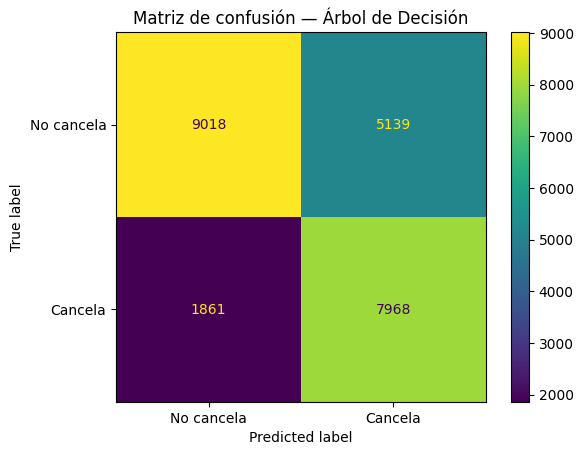

In [49]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree,
    display_labels=["No cancela", "Cancela"]
)

plt.title("Matriz de confusión — Árbol de Decisión")
plt.show()

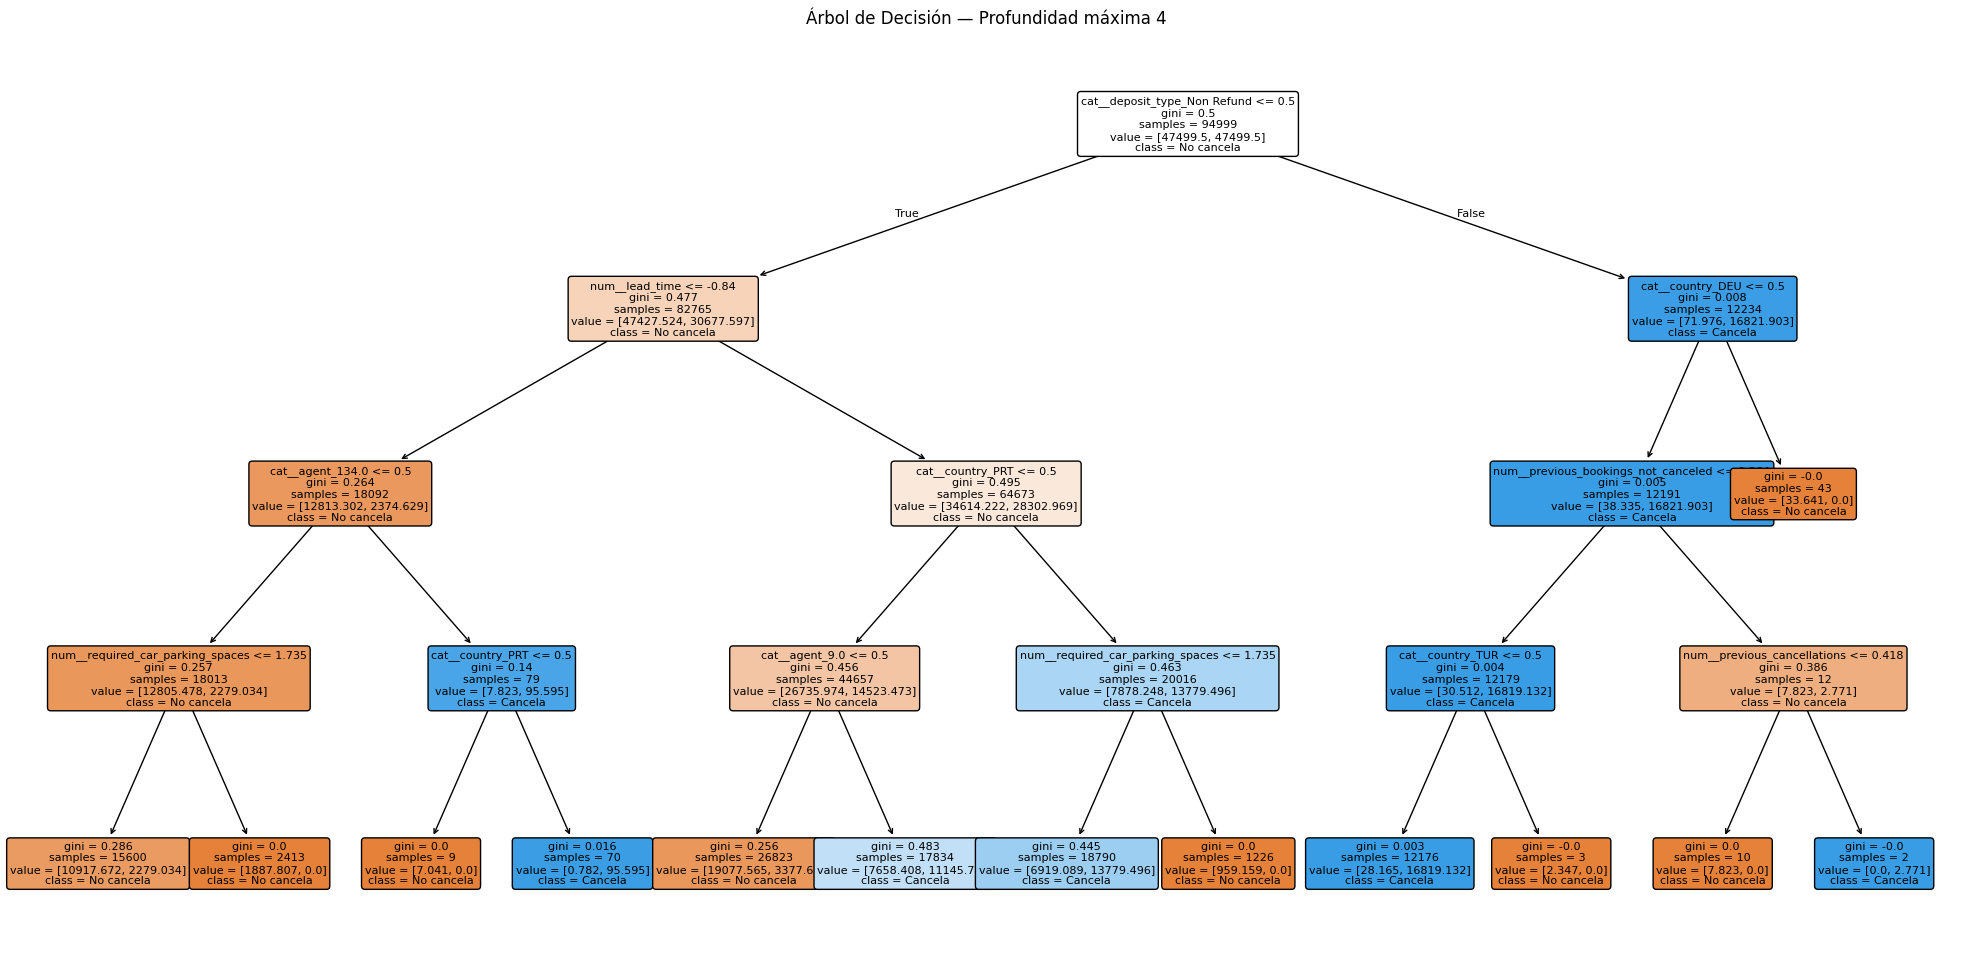

In [50]:
tree = decision_tree_model.named_steps["model"]

feature_names = (
    decision_tree_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

plt.figure(figsize=(25, 12))

plot_tree(
    tree,
    feature_names=feature_names,
    class_names=["No cancela", "Cancela"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Árbol de Decisión — Profundidad máxima 4")
plt.show()

Generamos unos cuantos árboles para poder comparar con distintas profundidades y nos lo guardamos para la tabla final y ver el mejor resultado

In [51]:
modelos_arboles = {4: decision_tree_model}

# Entrenamos las otras profundidades
for profundidad in [2, 6, 8]:

    modelo = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", DecisionTreeClassifier(
            criterion="gini",
            max_depth=profundidad,
            class_weight="balanced",
            random_state=42
        ))
    ])

    modelo.fit(X_train, y_train)
    modelos_arboles[profundidad] = modelo

# Evaluamos todos, incluido el primer árbol
resultados_arboles = []

for profundidad, modelo in sorted(modelos_arboles.items()):

    prob_train = modelo.predict_proba(X_train)[:, 1]
    prob_test = modelo.predict_proba(X_test)[:, 1]
    pred_test = modelo.predict(X_test)

    auc_train = roc_auc_score(y_train, prob_train)
    auc_test = roc_auc_score(y_test, prob_test)

    resultados_arboles.append({
        "Name": f"Árbol — profundidad {profundidad}",
        "AUC Train": auc_train,
        "AUC Test": auc_test,
        "Diferencia AUC": auc_train - auc_test,
        "F1 Test": f1_score(
            y_test, pred_test, zero_division=0
        ),
        "Precision Test": precision_score(
            y_test, pred_test, zero_division=0
        ),
        "Recall Test": recall_score(
            y_test, pred_test, zero_division=0
        ),
        "Kappa Test": cohen_kappa_score(y_test, pred_test)
    })

#### 7.2.2 Random Forest

El objetivo es comprobar si combinar varios árboles mejora el
rendimiento respecto al árbol individual y la regresión logística.

Se utiliza `class_weight="balanced"` para ajustar el peso de las
clases según su frecuencia. Esta configuración es un punto de
partida y todavía no se ha optimizado.

In [52]:
random_forest_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](29,)","['hotel','lead_time','arrival_date_year',...,'total_guests','total_nights', 'total_stay_value']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remaind

Se obtienen las clases predichas y las probabilidades de cancelación
en Test. También se calcula el AUC en Train para comparar el
rendimiento entre entrenamiento y evaluación e identificar posibles
señales de sobreajuste.

Guardamos también el resultado

In [53]:
# Predicciones en Test
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Probabilidades en Train
prob_train_rf = random_forest_model.predict_proba(X_train)[:, 1]

# AUC
auc_train_rf = roc_auc_score(y_train, prob_train_rf)
auc_test_rf = roc_auc_score(y_test, y_prob_rf)

resultado_rf = {
    "Name": "Random Forest — 200 árboles, profundidad 8",
    "AUC Train": auc_train_rf,
    "AUC Test": auc_test_rf,
    "Diferencia AUC": auc_train_rf - auc_test_rf,
    "F1 Test": f1_score(y_test, y_pred_rf, zero_division=0),
    "Precision Test": precision_score(
        y_test, y_pred_rf, zero_division=0
    ),
    "Recall Test": recall_score(
        y_test, y_pred_rf, zero_division=0
    ),
    "Kappa Test": cohen_kappa_score(y_test, y_pred_rf)
}

La matriz permite distinguir las cancelaciones detectadas, las
cancelaciones que pasan inadvertidas y las falsas alarmas.

Estos errores tienen implicaciones distintas: una cancelación no
detectada reduce la capacidad de anticipación, mientras que una
falsa alarma puede generar una intervención innecesaria.

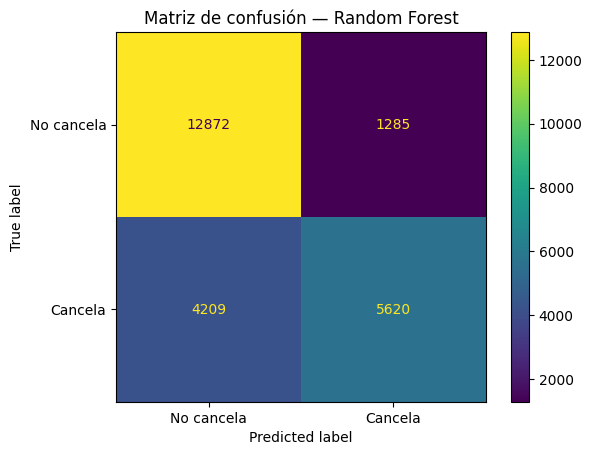

In [54]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["No cancela", "Cancela"]
)

plt.title("Matriz de confusión — Random Forest")
plt.show()

In [55]:
# Configuraciones iniciales
modelos_rf = {
    "RF — 200 árboles, profundidad 8, hoja 1, sqrt":
        random_forest_model
}

configuraciones_rf = [
    {
        "nombre": "RF — 200 árboles, profundidad 16, hoja 1, sqrt",
        "max_depth": 16,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },
    {
        "nombre": "RF — 200 árboles, profundidad 16, hoja 5, sqrt",
        "max_depth": 16,
        "min_samples_leaf": 5,
        "max_features": "sqrt"
    },
    {
        "nombre": "RF — 200 árboles, profundidad 16, hoja 5, 50%",
        "max_depth": 16,
        "min_samples_leaf": 5,
        "max_features": 0.5
    }
]

Se obtienen las clases predichas y las probabilidades de cancelación
en Test. También se calcula el AUC en Train para comparar el
rendimiento entre entrenamiento y evaluación e identificar posibles
señales de sobreajuste.

In [56]:
for configuracion in configuraciones_rf:

    print(f"Entrenando: {configuracion['nombre']}")

    modelo = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=configuracion["max_depth"],
            min_samples_leaf=configuracion["min_samples_leaf"],
            max_features=configuracion["max_features"],
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ])

    modelo.fit(X_train, y_train)
    modelos_rf[configuracion["nombre"]] = modelo

Entrenando: RF — 200 árboles, profundidad 16, hoja 1, sqrt
Entrenando: RF — 200 árboles, profundidad 16, hoja 5, sqrt
Entrenando: RF — 200 árboles, profundidad 16, hoja 5, 50%


Se registran el AUC de Train y Test, su diferencia, F1, precision
y recall, utilizando las mismas métricas que en los modelos
anteriores para facilitar la comparación.

In [57]:
resultados_rf = []
for nombre, modelo in modelos_rf.items():

    prob_train = modelo.predict_proba(X_train)[:, 1]
    prob_test = modelo.predict_proba(X_test)[:, 1]
    pred_test = modelo.predict(X_test)

    auc_train = roc_auc_score(y_train, prob_train)
    auc_test = roc_auc_score(y_test, prob_test)

    resultados_rf.append({
        "Name": nombre,
        "AUC Train": auc_train,
        "AUC Test": auc_test,
        "Diferencia AUC": auc_train - auc_test,
        "F1 Test": f1_score(
            y_test, pred_test, zero_division=0
        ),
        "Precision Test": precision_score(
            y_test, pred_test, zero_division=0
        ),
        "Recall Test": recall_score(
            y_test, pred_test, zero_division=0
        ),
        "Kappa Test": cohen_kappa_score(y_test, pred_test)
    })

#### 7.2.3 XGBoost

XGBoost construye árboles de forma secuencial, buscando reducir
los errores del conjunto en cada nueva iteración.

Se prueba una configuración inicial de 200 árboles, profundidad
máxima de 4 y una tasa de aprendizaje de 0,05. El objetivo es
comparar su rendimiento con los modelos anteriores.

In [58]:
peso_clases = (
    (y_train == 0).sum() / (y_train == 1).sum()
)

xgboost_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=peso_clases,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

xgboost_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](29,)","['hotel','lead_time','arrival_date_year',...,'total_guests','total_nights', 'total_stay_value']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remaind

Se obtienen las clases predichas y las probabilidades de cancelación
en Test. También se calcula el AUC en Train para comparar el
rendimiento entre entrenamiento y evaluación e identificar posibles
señales de sobreajuste.

Guardamos también el resultado

In [59]:
y_pred_xgb = xgboost_model.predict(X_test)
y_prob_xgb = xgboost_model.predict_proba(X_test)[:, 1]

prob_train_xgb = xgboost_model.predict_proba(X_train)[:, 1]

auc_train_xgb = roc_auc_score(y_train, prob_train_xgb)
auc_test_xgb = roc_auc_score(y_test, y_prob_xgb)

resultado_xgb = {
    "Name": "XGBoost — 200 árboles, profundidad 4, lr 0.05",
    "AUC Train": auc_train_xgb,
    "AUC Test": auc_test_xgb,
    "Diferencia AUC": auc_train_xgb - auc_test_xgb,
    "F1 Test": f1_score(y_test, y_pred_xgb, zero_division=0),
    "Precision Test": precision_score(
        y_test, y_pred_xgb, zero_division=0
    ),
    "Recall Test": recall_score(
        y_test, y_pred_xgb, zero_division=0
    ),
    "Kappa Test": cohen_kappa_score(y_test, y_pred_xgb)
}

La matriz permite distinguir las cancelaciones detectadas, las
cancelaciones que pasan inadvertidas y las falsas alarmas.

Estos errores tienen implicaciones distintas: una cancelación no
detectada reduce la capacidad de anticipación, mientras que una
falsa alarma puede generar una intervención innecesaria.

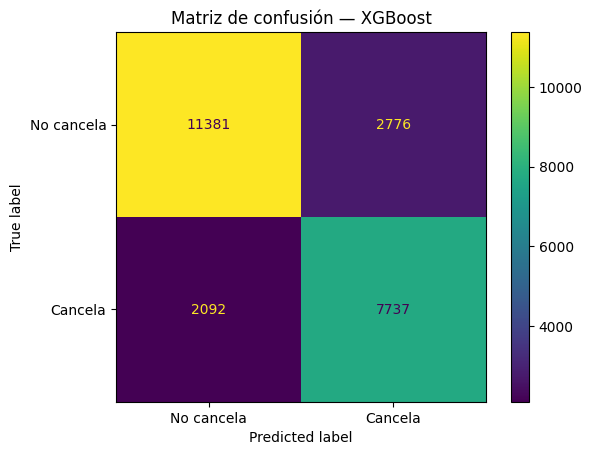

In [60]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=["No cancela", "Cancela"]
)

plt.title("Matriz de confusión — XGBoost")
plt.show()

In [61]:
#Configuraciones iniciales
modelos_xgb = {
    "XGBoost — 200 árboles, profundidad 4, lr 0.05":
        xgboost_model
}

configuraciones_xgb = [
    {
        "nombre": "XGBoost — 400 árboles, profundidad 4, lr 0.05",
        "n_estimators": 400,
        "max_depth": 4,
        "learning_rate": 0.05
    },
    {
        "nombre": "XGBoost — 200 árboles, profundidad 6, lr 0.05",
        "n_estimators": 200,
        "max_depth": 6,
        "learning_rate": 0.05
    },
    {
        "nombre": "XGBoost — 200 árboles, profundidad 4, lr 0.10",
        "n_estimators": 200,
        "max_depth": 4,
        "learning_rate": 0.10
    }
]

Se calculan las mismas métricas para las cuatro configuraciones.
Se compara su rendimiento en Test y la diferencia de AUC respecto
a Train para identificar posibles señales de sobreajuste.

In [62]:
for configuracion in configuraciones_xgb:

    nombre = configuracion["nombre"]
    print(f"Entrenando: {nombre}")

    modelo = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", XGBClassifier(
            n_estimators=configuracion["n_estimators"],
            max_depth=configuracion["max_depth"],
            learning_rate=configuracion["learning_rate"],
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=peso_clases,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            n_jobs=-1
        ))
    ])

    modelo.fit(X_train, y_train)
    modelos_xgb[nombre] = modelo

Entrenando: XGBoost — 400 árboles, profundidad 4, lr 0.05
Entrenando: XGBoost — 200 árboles, profundidad 6, lr 0.05
Entrenando: XGBoost — 200 árboles, profundidad 4, lr 0.10


Se registran el AUC de Train y Test, su diferencia, F1, precision
y recall, utilizando las mismas métricas que en los modelos
anteriores para facilitar la comparación.

In [63]:
resultados_xgb = []

for nombre, modelo in modelos_xgb.items():

    prob_train = modelo.predict_proba(X_train)[:, 1]
    prob_test = modelo.predict_proba(X_test)[:, 1]
    pred_test = modelo.predict(X_test)

    auc_train = roc_auc_score(y_train, prob_train)
    auc_test = roc_auc_score(y_test, prob_test)

    resultados_xgb.append({
        "Name": nombre,
        "AUC Train": auc_train,
        "AUC Test": auc_test,
        "Diferencia AUC": auc_train - auc_test,
        "F1 Test": f1_score(
            y_test, pred_test, zero_division=0
        ),
        "Precision Test": precision_score(
            y_test, pred_test, zero_division=0
        ),
        "Recall Test": recall_score(
            y_test, pred_test, zero_division=0
        ),
        "Kappa Test": cohen_kappa_score(y_test, pred_test)
    })

#### 7.2.4 LightGBM

Se entrena LightGBM con 400 árboles, una tasa de aprendizaje
de 0,05, un máximo de 31 hojas por árbol y un mínimo de
50 observaciones por hoja.

Se compara su rendimiento con los modelos anteriores.

In [64]:
from lightgbm import LGBMClassifier
from sklearn.base import clone

lightgbm_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=50,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ))
])

lightgbm_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](29,)","['hotel','lead_time','arrival_date_year',...,'total_guests','total_nights', 'total_stay_value']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remaind

Evaluar y guardar las métricas

In [65]:
y_pred_lgbm = lightgbm_model.predict(X_test)
y_prob_lgbm = lightgbm_model.predict_proba(X_test)[:, 1]

prob_train_lgbm = lightgbm_model.predict_proba(X_train)[:, 1]

auc_train_lgbm = roc_auc_score(y_train, prob_train_lgbm)
auc_test_lgbm = roc_auc_score(y_test, y_prob_lgbm)

resultado_lgbm = {
    "Name": "LightGBM — 400 árboles, 31 hojas, lr 0.05",
    "AUC Train": auc_train_lgbm,
    "AUC Test": auc_test_lgbm,
    "Diferencia AUC": auc_train_lgbm - auc_test_lgbm,
    "F1 Test": f1_score(
        y_test, y_pred_lgbm, zero_division=0
    ),
    "Precision Test": precision_score(
        y_test, y_pred_lgbm, zero_division=0
    ),
    "Recall Test": recall_score(
        y_test, y_pred_lgbm, zero_division=0
    ),
    "Kappa Test": cohen_kappa_score(y_test, y_pred_lgbm)
}

Matriz de confusión

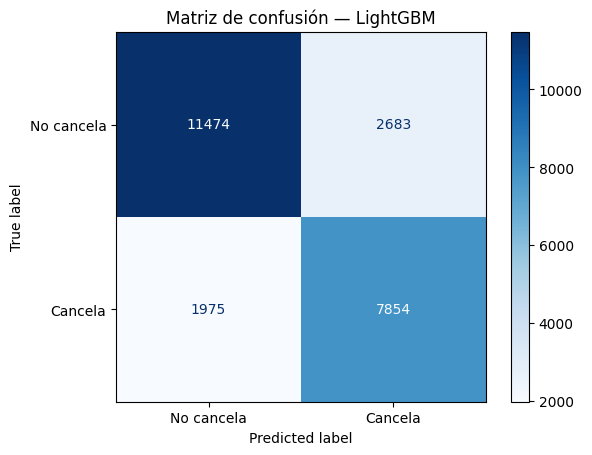

In [66]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lgbm,
    display_labels=["No cancela", "Cancela"],
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de confusión — LightGBM")
plt.show()

#### 7.2.5 SVM lineal

Se entrena un SVM lineal con las variables numéricas escaladas
mediante el preprocesador existente.

Se utiliza `C=1.0` como configuración inicial y
`class_weight="balanced"` para ajustar el peso de las clases.
El objetivo es comparar este modelo con los anteriores.

In [67]:
svm_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", LinearSVC(
        C=1.0,
        class_weight="balanced",
        dual=False,
        max_iter=10000,
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](29,)","['hotel','lead_time','arrival_date_year',...,'total_guests','total_nights', 'total_stay_value']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remaind

Evaluar y guardar los resultados

In [68]:
from sklearn.metrics import cohen_kappa_score

y_pred_svm = svm_model.predict(X_test)

score_train_svm = svm_model.decision_function(X_train)
score_test_svm = svm_model.decision_function(X_test)

auc_train_svm = roc_auc_score(y_train, score_train_svm)
auc_test_svm = roc_auc_score(y_test, score_test_svm)

resultado_svm = {
    "Name": "SVM lineal — C=1.0",
    "AUC Train": auc_train_svm,
    "AUC Test": auc_test_svm,
    "Diferencia AUC": auc_train_svm - auc_test_svm,
    "F1 Test": f1_score(
        y_test, y_pred_svm, zero_division=0
    ),
    "Precision Test": precision_score(
        y_test, y_pred_svm, zero_division=0
    ),
    "Recall Test": recall_score(
        y_test, y_pred_svm, zero_division=0
    ),
    "Kappa Test": cohen_kappa_score(y_test, y_pred_svm)
}

Matriz de confusión

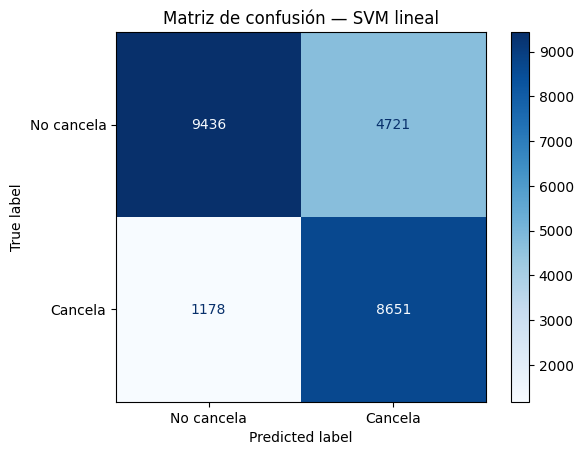

In [69]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels=["No cancela", "Cancela"],
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de confusión — SVM lineal")
plt.show()

### 7.3 Resultados de la comparación exploratoria

Se reúnen las métricas de los modelos sobre Train y Test.

Test no se utiliza para ajustar los parámetros aprendidos durante
el entrenamiento, pero sus resultados se han consultado para
orientar la comparación. Por tanto, no constituye una evaluación
final independiente.

In [70]:
resultados_modelos = (
    [resultado_logistic]
    + resultados_arboles
    + resultados_rf
    + resultados_xgb
    + [resultado_lgbm, resultado_svm]
)

tabla_modelos = pd.DataFrame(resultados_modelos)

display(
    tabla_modelos.style.format({
        "AUC Train": "{:.3f}",
        "AUC Test": "{:.3f}",
        "Diferencia AUC": "{:.3f}",
        "F1 Test": "{:.3f}",
        "Precision Test": "{:.3f}",
        "Recall Test": "{:.3f}",
        "Kappa Test": "{:.3f}"
    })
)

,Name,AUC Train,AUC Test,Diferencia AUC,F1 Test,Precision Test,Recall Test,Kappa Test
0,Regresión Logística,0.916,0.871,0.045,0.748,0.650,0.881,0.523
1,Árbol — profundidad 2,0.739,0.666,0.073,0.386,1.000,0.239,0.270
2,Árbol — profundidad 4,0.853,0.779,0.074,0.695,0.608,0.811,0.426
3,Árbol — profundidad 6,0.911,0.855,0.056,0.716,0.749,0.685,0.533
4,Árbol — profundidad 8,0.930,0.870,0.060,0.701,0.793,0.629,0.532
5,"RF — 200 árboles, profundidad 8, hoja 1, sqrt",0.918,0.860,0.058,0.672,0.814,0.572,0.504
6,"RF — 200 árboles, profundidad 16, hoja 1, sqrt",0.959,0.876,0.083,0.719,0.789,0.661,0.552
7,"RF — 200 árboles, profundidad 16, hoja 5, sqrt",0.946,0.877,0.069,0.713,0.797,0.644,0.546
8,"RF — 200 árboles, profundidad 16, hoja 5, 50%",0.974,0.892,0.081,0.764,0.732,0.799,0.588
9,"XGBoost — 200 árboles, profundidad 4, lr 0.05",0.944,0.887,0.056,0.761,0.736,0.787,0.585


### 7.4. Comparación de los candidatos finales

Se propone LightGBM como candidato principal por obtener el
mayor AUC Test (0,898), criterio principal de comparación,
y el mayor Kappa (0,603).

XGBoost con 400 árboles y profundidad 4 se mantiene como
alternativa por su F1 y recall ligeramente superiores.

La elección es provisional y se contrastará mediante
validación cruzada temporal dentro de Train.

Evaluar los dos modelos ya entrenados

In [71]:
parametros_lgbm = lightgbm_model.named_steps["model"].get_params()

nombre_lgbm = (
    f"LightGBM — {parametros_lgbm['n_estimators']} árboles, "
    f"{parametros_lgbm['num_leaves']} hojas, "
    f"lr {parametros_lgbm['learning_rate']}"
)

nombre_xgb = "XGBoost — 400 árboles, profundidad 4, lr 0.05"

candidatos_finales = {
    nombre_xgb: modelos_xgb[nombre_xgb],
    nombre_lgbm: lightgbm_model
}

resultados_candidatos = []
predicciones_candidatos = {}

for nombre, modelo in candidatos_finales.items():

    pred_test = modelo.predict(X_test)
    prob_test = modelo.predict_proba(X_test)[:, 1]
    prob_train = modelo.predict_proba(X_train)[:, 1]

    auc_train = roc_auc_score(y_train, prob_train)
    auc_test = roc_auc_score(y_test, prob_test)

    predicciones_candidatos[nombre] = {
        "pred": pred_test,
        "prob": prob_test
    }

    resultados_candidatos.append({
        "Name": nombre,
        "AUC Train": auc_train,
        "AUC Test": auc_test,
        "Diferencia AUC": auc_train - auc_test,
        "F1 Test": f1_score(
            y_test, pred_test, zero_division=0
        ),
        "Precision Test": precision_score(
            y_test, pred_test, zero_division=0
        ),
        "Recall Test": recall_score(
            y_test, pred_test, zero_division=0
        ),
        "Kappa Test": cohen_kappa_score(y_test, pred_test)
    })

tabla_candidatos = pd.DataFrame(resultados_candidatos)

display(
    tabla_candidatos.style.format({
        "AUC Train": "{:.3f}",
        "AUC Test": "{:.3f}",
        "Diferencia AUC": "{:.3f}",
        "F1 Test": "{:.3f}",
        "Precision Test": "{:.3f}",
        "Recall Test": "{:.3f}",
        "Kappa Test": "{:.3f}"
    })
)

,Name,AUC Train,AUC Test,Diferencia AUC,F1 Test,Precision Test,Recall Test,Kappa Test
0,"XGBoost — 400 árboles, profundidad 4, lr 0.05",0.951,0.894,0.057,0.774,0.732,0.821,0.600
1,"LightGBM — 400 árboles, 31 hojas, lr 0.05",0.966,0.898,0.068,0.771,0.745,0.799,0.603


Matrices de confusión una al lado de la otra

Usamos la misma escala de color para que la comparación sea consistente.

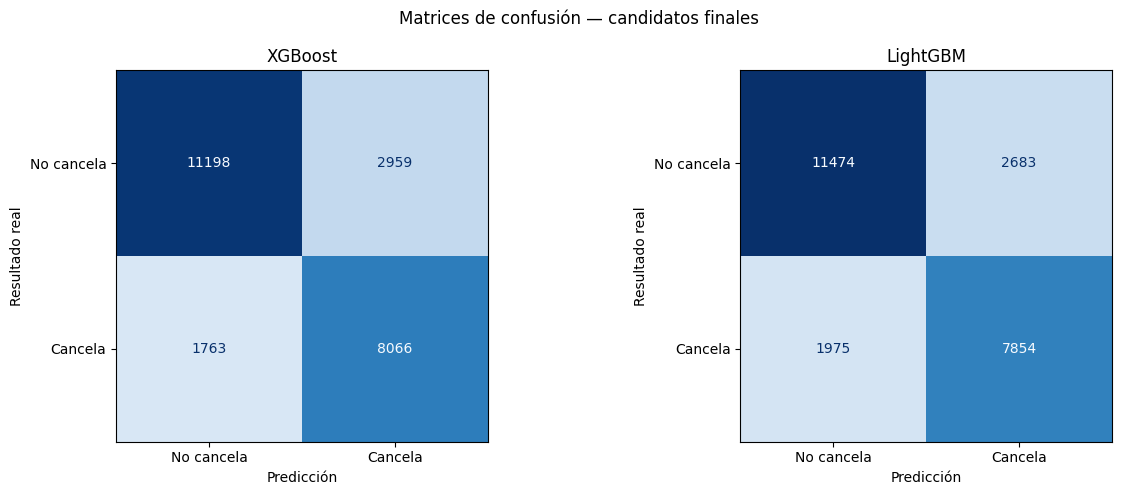

In [72]:
matrices = {
    nombre: confusion_matrix(
        y_test, datos["pred"], labels=[0, 1]
    )
    for nombre, datos in predicciones_candidatos.items()
}

maximo = max(matriz.max() for matriz in matrices.values())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (nombre, matriz) in zip(axes, matrices.items()):

    visualizacion = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=["No cancela", "Cancela"]
    )

    visualizacion.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    visualizacion.im_.set_clim(0, maximo)

    ax.set_title(nombre.split(" — ")[0])
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Resultado real")

fig.suptitle("Matrices de confusión — candidatos finales")
plt.tight_layout()
plt.show()

Las dos curvas ROC en un mismo gráfico

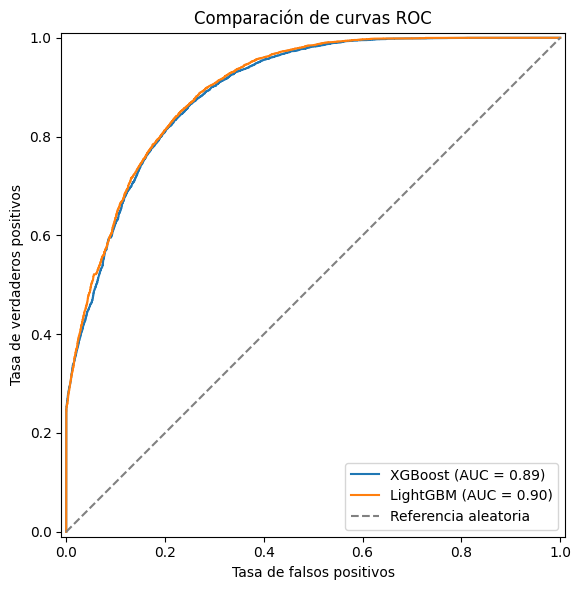

In [73]:
fig, ax = plt.subplots(figsize=(8, 6))

for nombre, datos in predicciones_candidatos.items():

    RocCurveDisplay.from_predictions(
        y_test,
        datos["prob"],
        name=nombre.split(" — ")[0],
        ax=ax
    )

ax.plot(
    [0, 1], [0, 1],
    linestyle="--",
    color="gray",
    label="Referencia aleatoria"
)

ax.set_title("Comparación de curvas ROC")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

Tabla con los aciertos y errores de ambos

In [74]:
resumen_errores = []

for nombre, matriz in matrices.items():

    tn, fp, fn, tp = matriz.ravel()

    resumen_errores.append({
        "Modelo": nombre.split(" — ")[0],
        "No canceladas bien clasificadas": tn,
        "Falsas alarmas": fp,
        "Cancelaciones no detectadas": fn,
        "Cancelaciones detectadas": tp
    })

display(pd.DataFrame(resumen_errores))

,Modelo,No canceladas bien clasificadas,Falsas alarmas,Cancelaciones no detectadas,Cancelaciones detectadas
0,XGBoost,11198,2959,1763,8066
1,LightGBM,11474,2683,1975,7854


**Interpretación:** Según los resultados obtenidos, LightGBM
ofrece alertas algo más precisas, mientras que XGBoost detecta
una mayor proporción de cancelaciones.

Las matrices de confusión permiten cuantificar ese intercambio:
cuántas falsas alarmas y cancelaciones no detectadas genera cada
modelo con el umbral actual de 0,5.

Las curvas ROC comparan su capacidad de discriminación a distintos
umbrales. La pequeña diferencia de AUC no permite afirmar que uno
sea claramente superior.

Ambos se mantienen como candidatos. La elección del modelo y del
umbral debe realizarse en validación, considerando el coste de
intervenir sobre una falsa alarma y el de no detectar una cancelación.

---
## 8. Optimización con validación cruzada temporal

Se selecciona **LightGBM** por obtener el mayor AUC medio en
validación cruzada temporal: **0,881**, frente a **0,879**
de XGBoost.

Además, presenta una menor desviación entre los tres periodos:
**0,022 frente a 0,033**. Esto indica un comportamiento menos
variable en las particiones analizadas, aunque la diferencia
de rendimiento medio es pequeña.

La configuración seleccionada utiliza **400 árboles, 31 hojas,
una tasa de aprendizaje de 0,05 y un mínimo de 20 observaciones
por hoja**.

La selección se basa en validación temporal. No constituye una
evaluación independiente, ya que esas particiones se han utilizado
para elegir los hiperparámetros.

Crear las tres particiones temporales

In [75]:
# Orden temporal
train_cv = (
    train.sort_values("arrival_date")
    .reset_index(drop=True)
)

X_cv = train_cv[X_train.columns]
y_cv = train_cv["is_canceled"]

# Dividimos fechas, no filas, para no repartir un mismo día
fechas = np.sort(train_cv["arrival_date"].unique())

divisor = TimeSeriesSplit(n_splits=3)
particiones_cv = []
resumen_particiones = []

for numero, (idx_fechas_train, idx_fechas_val) in enumerate(
    divisor.split(fechas), start=1
):

    fechas_train = fechas[idx_fechas_train]
    fechas_val = fechas[idx_fechas_val]

    idx_train = np.flatnonzero(
        train_cv["arrival_date"].isin(fechas_train).to_numpy()
    )
    idx_val = np.flatnonzero(
        train_cv["arrival_date"].isin(fechas_val).to_numpy()
    )

    assert y_cv.iloc[idx_train].nunique() == 2
    assert y_cv.iloc[idx_val].nunique() == 2

    particiones_cv.append((idx_train, idx_val))

    resumen_particiones.append({
        "Partición": numero,
        "Inicio entrenamiento": pd.Timestamp(fechas_train.min()).date(),
        "Fin entrenamiento": pd.Timestamp(fechas_train.max()).date(),
        "Inicio validación": pd.Timestamp(fechas_val.min()).date(),
        "Fin validación": pd.Timestamp(fechas_val.max()).date(),
        "Reservas entrenamiento": len(idx_train),
        "Reservas validación": len(idx_val)
    })

display(pd.DataFrame(resumen_particiones))

,Partición,Inicio entrenamiento,Fin entrenamiento,Inicio validación,Fin validación,Reservas entrenamiento,Reservas validación
0,1,2015-07-01,2015-12-13,2015-12-14,2016-05-26,20439,22552
1,2,2015-07-01,2016-05-26,2016-05-27,2016-11-07,42991,28699
2,3,2015-07-01,2016-11-07,2016-11-08,2017-04-21,71690,23309


Tres evaluaciones, cada una entrenando con el pasado y validando sobre un periodo posterior.

In [76]:
modelos_busqueda = {
    "XGBoost": clone(
        modelos_xgb["XGBoost — 200 árboles, profundidad 6, lr 0.05"]
    ),
    "LightGBM": clone(lightgbm_model)
}

# Evitamos paralelismo simultáneo entre modelos y búsquedas
for modelo in modelos_busqueda.values():
    modelo.set_params(model__n_jobs=-1)

# El peso de XGBoost también será un hiperparámetro fijo por prueba.
# Así no se calcula usando las etiquetas del periodo de validación.
espacios_busqueda = {
    "XGBoost": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [3, 4, 6],
        "model__learning_rate": [0.03, 0.05, 0.10],
        "model__scale_pos_weight": [1, 2, 3]
    },
    "LightGBM": {
        "model__n_estimators": [200, 400],
        "model__num_leaves": [15, 31],
        "model__min_child_samples": [20, 50],
        "model__learning_rate": [0.03, 0.05]
    }
}

Ejecutar la optimización

In [77]:
busquedas = {}
modelos_optimizados = {}
resumen_optimizacion = []

for nombre, modelo in modelos_busqueda.items():

    print(f"\nOptimizando {nombre}...")

    busqueda = RandomizedSearchCV(
        estimator=modelo,
        param_distributions=espacios_busqueda[nombre],
        n_iter=6,
        scoring="roc_auc",
        cv=particiones_cv,
        refit=True,
        random_state=42,
        n_jobs=1,
        verbose=1,
        error_score="raise"
    )

    busqueda.fit(X_cv, y_cv)

    busquedas[nombre] = busqueda
    modelos_optimizados[nombre] = busqueda.best_estimator_

    indice = busqueda.best_index_

    resumen_optimizacion.append({
        "Modelo": nombre,
        "AUC medio CV": busqueda.best_score_,
        "Desviación AUC CV": (
            busqueda.cv_results_["std_test_score"][indice]
        )
    })

    print("Mejores parámetros:")
    print({
        clave.replace("model__", ""): valor
        for clave, valor in busqueda.best_params_.items()
    })

tabla_optimizacion = pd.DataFrame(resumen_optimizacion)

display(
    tabla_optimizacion.style.format({
        "AUC medio CV": "{:.3f}",
        "Desviación AUC CV": "{:.3f}"
    })
)


Optimizando XGBoost...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Mejores parámetros:
{'scale_pos_weight': 1, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}

Optimizando LightGBM...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Mejores parámetros:
{'num_leaves': 31, 'n_estimators': 400, 'min_child_samples': 20, 'learning_rate': 0.05}


,Modelo,AUC medio CV,Desviación AUC CV
0,XGBoost,0.879,0.033
1,LightGBM,0.881,0.022


Mostrar cómo rindieron en cada periodo

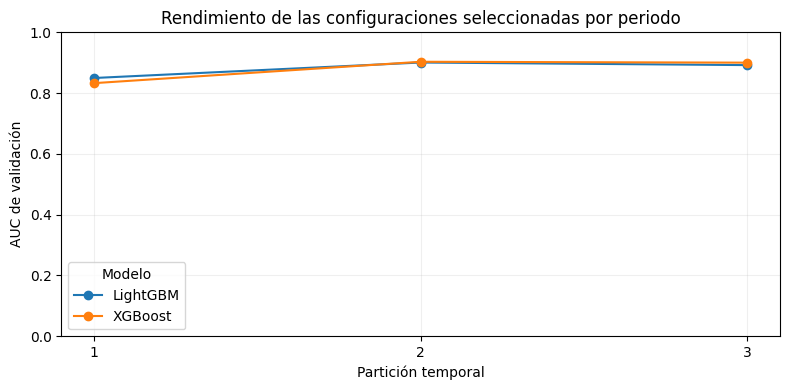

In [78]:
resultados_por_periodo = []

for nombre, busqueda in busquedas.items():

    indice = busqueda.best_index_

    for numero in range(len(particiones_cv)):
        resultados_por_periodo.append({
            "Modelo": nombre,
            "Partición": numero + 1,
            "AUC Validación": busqueda.cv_results_[
                f"split{numero}_test_score"
            ][indice]
        })

tabla_periodos = pd.DataFrame(resultados_por_periodo)

tabla_periodos.pivot(
    index="Partición",
    columns="Modelo",
    values="AUC Validación"
).plot(marker="o", figsize=(8, 4))

plt.title("Rendimiento de las configuraciones seleccionadas por periodo")
plt.ylabel("AUC de validación")
plt.xlabel("Partición temporal")
plt.xticks([1, 2, 3])
plt.ylim(0, 1)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Interpretación:** El AUC medio resume el rendimiento en los
tres periodos de validación. La desviación y el gráfico permiten
examinar cuánto cambia ese rendimiento entre periodos.

La mejor configuración se selecciona por su AUC medio.
Estos resultados se han utilizado para seleccionar parámetros,
por lo que no equivalen a una evaluación final independiente.

**Interpretación:** El umbral determina el equilibrio entre
cancelaciones detectadas y falsas alarmas. Al reducirlo se generan
más alertas y el recall no disminuye; la precision puede variar.

El AUC no cambia al modificar únicamente el umbral, porque se
calcula sobre las puntuaciones del modelo.

Los umbrales seleccionados maximizan F1 dentro de esta validación.
Sus resultados no son una estimación independiente del rendimiento
futuro y deberían contrastarse en otros periodos.

### 8.1. Selección del modelo final

Se selecciona **LightGBM** por obtener el mayor AUC medio en
validación cruzada temporal: **0,881**, frente a **0,879**
de XGBoost.

Además, presenta una menor desviación entre los tres periodos:
**0,022 frente a 0,033**. Esto indica un comportamiento menos
variable en las particiones analizadas, aunque la diferencia
de rendimiento medio es pequeña.

La configuración seleccionada utiliza **400 árboles, 31 hojas,
una tasa de aprendizaje de 0,05 y un mínimo de 20 observaciones
por hoja**.

La selección se basa en validación temporal. No constituye una
evaluación independiente, ya que esas particiones se han utilizado
para elegir los hiperparámetros.

In [79]:
# Selección por mayor AUC medio de validación
nombre_modelo_final = (
    tabla_optimizacion
    .sort_values(
        ["AUC medio CV", "Desviación AUC CV"],
        ascending=[False, True]
    )
    .iloc[0]["Modelo"]
)

# Ya está entrenado con todo Train gracias a refit=True
modelo_final = modelos_optimizados[nombre_modelo_final]

print(f"Modelo seleccionado: {nombre_modelo_final}")

print("Parámetros seleccionados:")
print({
    clave.replace("model__", ""): valor
    for clave, valor in busquedas[nombre_modelo_final].best_params_.items()
})

Modelo seleccionado: LightGBM
Parámetros seleccionados:
{'num_leaves': 31, 'n_estimators': 400, 'min_child_samples': 20, 'learning_rate': 0.05}


---
## 9. Interpretabilidad

Se utiliza SHAP para analizar qué características contribuyen
a las predicciones del LightGBM seleccionado.

El análisis incluye una visión global y la explicación de dos
reservas concretas: una con puntuación de riesgo alta y otra baja.

Se utiliza una muestra de Test con fines descriptivos, sin ajustar
el modelo ni sus parámetros a partir de estas explicaciones.

In [80]:
X_shap = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=42
).copy()

y_shap = y_test.loc[X_shap.index]

# Componentes del pipeline final
preprocesador_final = modelo_final.named_steps["preprocessor"]
modelo_lgbm_final = modelo_final.named_steps["model"]

assert list(modelo_lgbm_final.classes_) == [0, 1]

# Transformar con el preprocesador ya ajustado
X_transformado = preprocesador_final.transform(X_shap)

if hasattr(X_transformado, "toarray"):
    X_transformado = X_transformado.toarray()

nombres_variables = preprocesador_final.get_feature_names_out()

# Explicar la salida del LightGBM
explainer = shap.TreeExplainer(
    modelo_lgbm_final,
    model_output="raw",
    feature_perturbation="tree_path_dependent"
)

valores_shap = explainer(X_transformado)

# Compatibilidad si la versión devuelve una dimensión por clase
if valores_shap.values.ndim == 3:
    valores_shap = valores_shap[:, :, 1]

valores_shap.feature_names = nombres_variables.tolist()

# Puntuaciones de cancelación para seleccionar los ejemplos
probabilidades_shap = modelo_final.predict_proba(X_shap)[:, 1]

El gráfico summary muestra las variables transformadas con
mayor importancia, ordenadas por su contribución SHAP absoluta
media en la muestra.

Cada punto representa una reserva:

- A la derecha: contribución hacia mayor riesgo de cancelación.
- A la izquierda: contribución hacia menor riesgo.
- Rojo: valor alto de la variable.
- Azul: valor bajo de la variable.

En las variables codificadas mediante One-Hot Encoding, 1 indica
que la categoría está presente y 0 que está ausente.

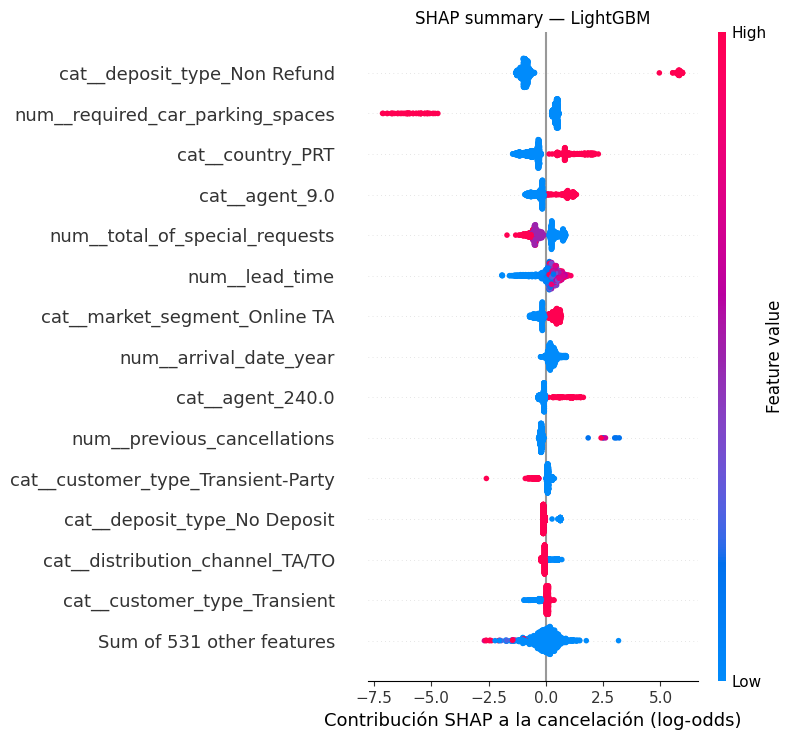

In [81]:
shap.plots.beeswarm(
    valores_shap,
    max_display=15,
    show=False
)

plt.title("SHAP summary — LightGBM")
plt.xlabel("Contribución SHAP a la cancelación (log-odds)")
plt.tight_layout()
plt.show()

Se seleccionan las reservas con mayor y menor puntuación de
cancelación dentro de la muestra analizada.

Son ejemplos contrastantes, no perfiles representativos de todas
las reservas. Se muestran sus características originales y el
resultado observado para contextualizar las explicaciones.

In [82]:
orden_riesgo = np.argsort(probabilidades_shap)

pos_baja = int(orden_riesgo[0])
pos_alta = int(orden_riesgo[-1])

casos = {
    "Mayor riesgo en la muestra": pos_alta,
    "Menor riesgo en la muestra": pos_baja
}

columnas_perfil = [
    "hotel",
    "country",
    "agent",
    "deposit_type",
    "lead_time",
    "market_segment",
    "adr",
    "total_nights",
    "is_repeated_guest",
    "total_of_special_requests"
]

columnas_perfil = [
    columna for columna in columnas_perfil
    if columna in X_shap.columns
]

perfiles = X_shap.iloc[
    [pos_alta, pos_baja]
][columnas_perfil].copy()

perfiles.insert(
    0,
    "Caso",
    ["Mayor riesgo en la muestra", "Menor riesgo en la muestra"]
)

perfiles.insert(
    1,
    "Puntuación de cancelación",
    probabilidades_shap[[pos_alta, pos_baja]]
)

perfiles.insert(
    2,
    "Resultado observado",
    [
        "Cancelada" if y_shap.iloc[pos] == 1 else "No cancelada"
        for pos in [pos_alta, pos_baja]
    ]
)

display(
    perfiles.style.format({
        "Puntuación de cancelación": "{:.1%}"
    })
)

,Caso,Puntuación de cancelación,Resultado observado,hotel,country,agent,deposit_type,lead_time,market_segment,adr,total_nights,is_repeated_guest,total_of_special_requests
103135,Mayor riesgo en la muestra,100.0%,Cancelada,City Hotel,PRT,58.0,Non Refund,174,Groups,100.000000,2,0,0
114817,Menor riesgo en la muestra,0.0%,No cancelada,Resort Hotel,CN,508.0,No Deposit,22,Online TA,241.410000,3,0,1


Cada waterfall parte del valor base del modelo y suma las
contribuciones de las características de una reserva hasta
alcanzar su puntuación final.

Las contribuciones rojas aumentan la puntuación de cancelación
y las azules la reducen. Los valores del eje se expresan en
log-odds, no en porcentajes.

Las contribuciones explican el comportamiento del modelo,
no las causas reales de una cancelación.


Mayor riesgo en la muestra
Puntuación de cancelación: 100.0%


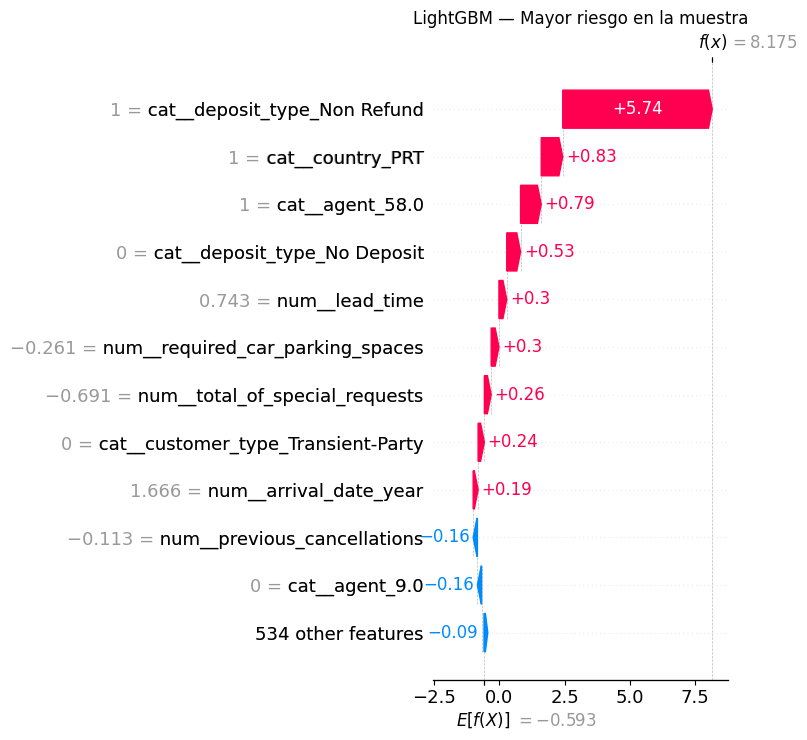


Menor riesgo en la muestra
Puntuación de cancelación: 0.0%


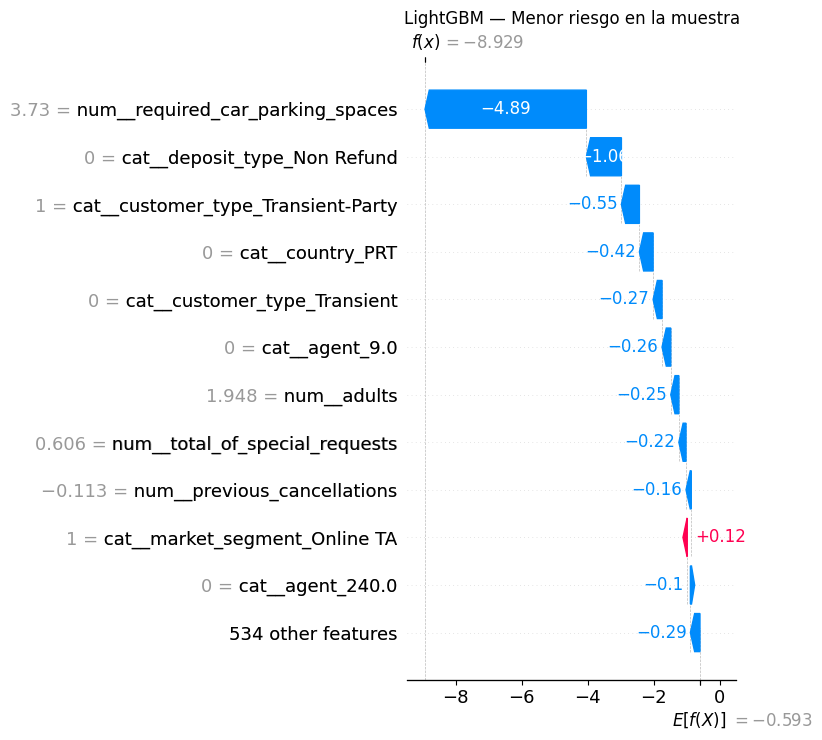

In [83]:
for nombre_caso, posicion in casos.items():

    print(f"\n{nombre_caso}")
    print(
        "Puntuación de cancelación: "
        f"{probabilidades_shap[posicion]:.1%}"
    )

    shap.plots.waterfall(
        valores_shap[posicion],
        max_display=12,
        show=False
    )

    plt.title(f"LightGBM — {nombre_caso}")
    plt.tight_layout()
    plt.show()

In [84]:
contribuciones_alta = pd.DataFrame({
    "Característica transformada": nombres_variables,
    "Valor transformado": X_transformado[pos_alta],
    "Contribución SHAP": valores_shap.values[pos_alta]
})

factores_aumentan = (
    contribuciones_alta.loc[
        contribuciones_alta["Contribución SHAP"] > 0
    ]
    .sort_values("Contribución SHAP", ascending=False)
    .head(5)
)

factores_reducen = (
    contribuciones_alta.loc[
        contribuciones_alta["Contribución SHAP"] < 0
    ]
    .sort_values("Contribución SHAP")
    .head(5)
)

print("Factores que más aumentan la puntuación de esta reserva:")
display(factores_aumentan.round(3))

print("Factores que más reducen la puntuación de esta reserva:")
display(factores_reducen.round(3))

Factores que más aumentan la puntuación de esta reserva:


,Característica transformada,Valor transformado,Contribución SHAP
225,cat__deposit_type_Non Refund,1.0000,5.7440
162,cat__country_PRT,1.0000,0.8260
498,cat__agent_58.0,1.0000,0.7930
224,cat__deposit_type_No Deposit,0.0000,0.5310
0,num__lead_time,0.7430,0.2990


Factores que más reducen la puntuación de esta reserva:


,Característica transformada,Valor transformado,Contribución SHAP
9,num__previous_cancellations,-0.1130,-0.1630
528,cat__agent_9.0,0.0000,-0.1600
208,cat__market_segment_Online TA,0.0000,-0.1580
329,cat__agent_240.0,0.0000,-0.0710
11,num__adr,0.1470,-0.0360


**Conclusión de negocio**

El EDA identifica una mayor tasa de cancelación en reservas
con mucha antelación y diferencias según hotel y canal.

SHAP permite examinar cómo combina LightGBM las características
de cada reserva para asignarle una puntuación de riesgo.
Los waterfall muestran qué factores aumentan o reducen esa
puntuación en los dos casos seleccionados.

Estas explicaciones pueden apoyar la priorización de
reconfirmaciones y seguimiento. No justifican atribuir causalidad
a una característica ni aplicar medidas automáticas basadas
únicamente en el país de origen.

Para describir el perfil concreto de mayor riesgo se deben
combinar los valores originales de la reserva con las
contribuciones positivas observadas en su waterfall.

---
## 10. Conclusiones y limitaciones

El análisis exploratorio identifica diferencias de cancelación
asociadas al hotel, el canal y la antelación de la reserva.
Estos patrones orientan el seguimiento preventivo, sin demostrar
relaciones causales.

Tras comparar varias familias de modelos y optimizar los candidatos,
se selecciona **LightGBM**, con un AUC medio de **0,881** en
validación cruzada temporal y una desviación de **0,022**.

La configuración seleccionada utiliza 400 árboles, 31 hojas,
una tasa de aprendizaje de 0,05 y un mínimo de 20 observaciones
por hoja.

La diferencia respecto a XGBoost es pequeña. La elección responde
al mayor AUC medio y a la menor variación observada entre periodos,
sin demostrar una superioridad general en cualquier escenario.

### Limitaciones

- Los resultados dependen de la limpieza y la población analizada.
- La partición temporal utiliza la fecha de llegada, no el momento
  exacto en que se emitiría la predicción.
- Test se consultó durante la exploración y no constituye una
  evaluación final independiente.
- Los resultados de validación se utilizaron para seleccionar
  hiperparámetros.
- No se han estimado costes de intervención ni ajustado un umbral
  específico para el negocio.

### Aplicación y próximos pasos

El modelo puede servir para priorizar el seguimiento de reservas
con mayor riesgo de cancelación.

Antes de implantarlo, se deben comprobar la disponibilidad de
las variables al predecir, la calibración de las probabilidades
y el rendimiento en nuevos periodos.

Finalmente, debe evaluarse un piloto con grupo de control para
comprobar si las actuaciones reducen las cancelaciones y generan
beneficio.

Tiempo total en ejecutar el notebook:

In [85]:
tiempo_total = perf_counter() - inicio_notebook
minutos, segundos = divmod(tiempo_total, 60)

print(f"Tiempo total: {int(minutos)} min {segundos:.1f} s")

Tiempo total: 7 min 18.4 s
